In [ ]:
import pandas as pd

df = pd.read_csv('/content/diabetic_data.csv', na_values='?')
display(df.head())

/tmp/ipython-input-3639080421.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/diabetic_data.csv', na_values='?')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Numerical columns:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical columns:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


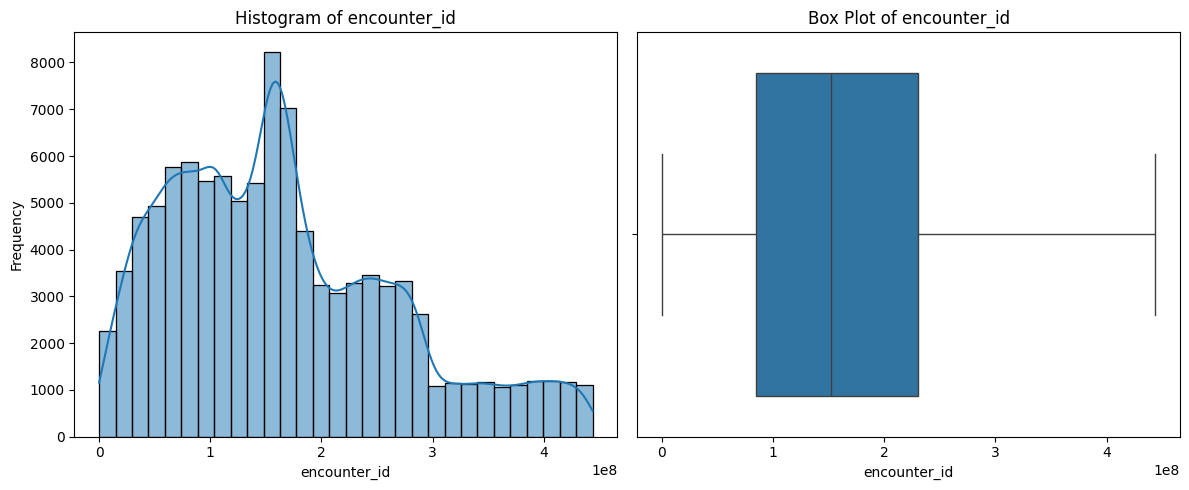

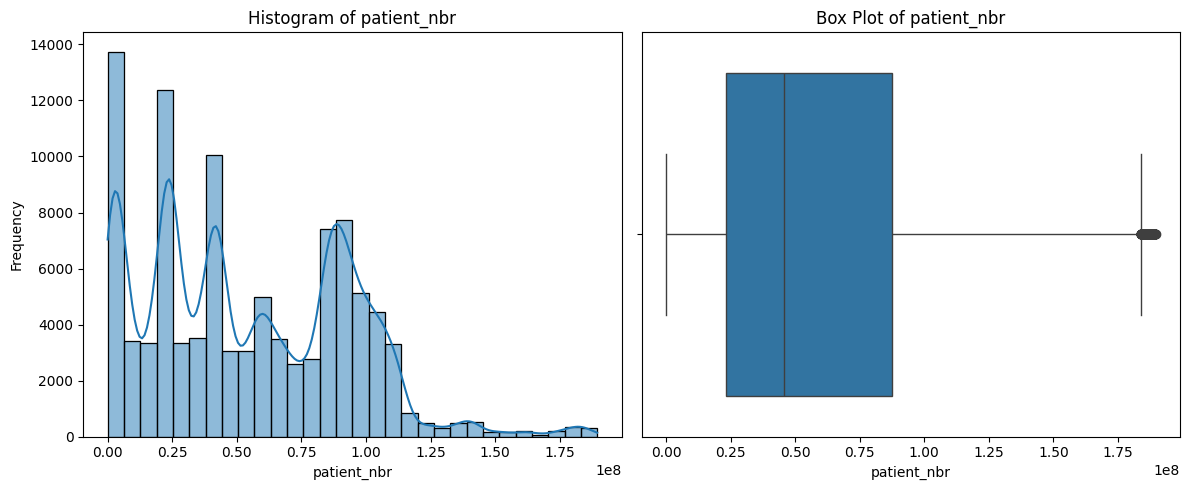

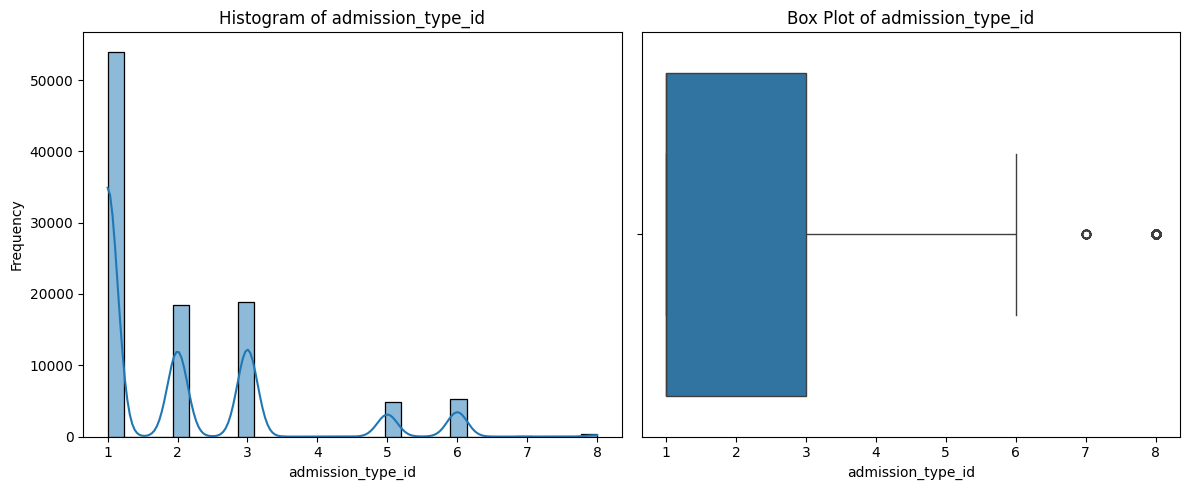

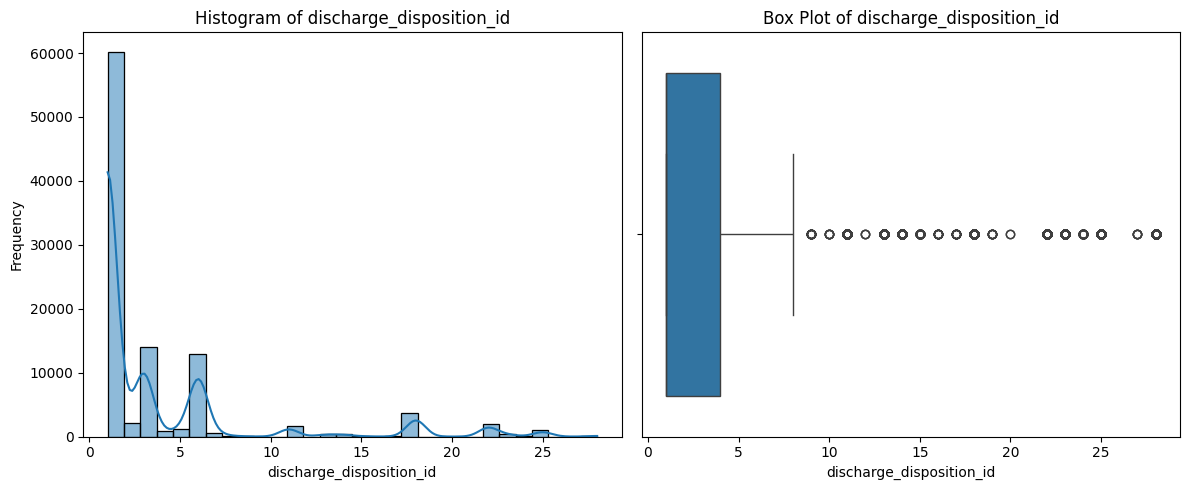

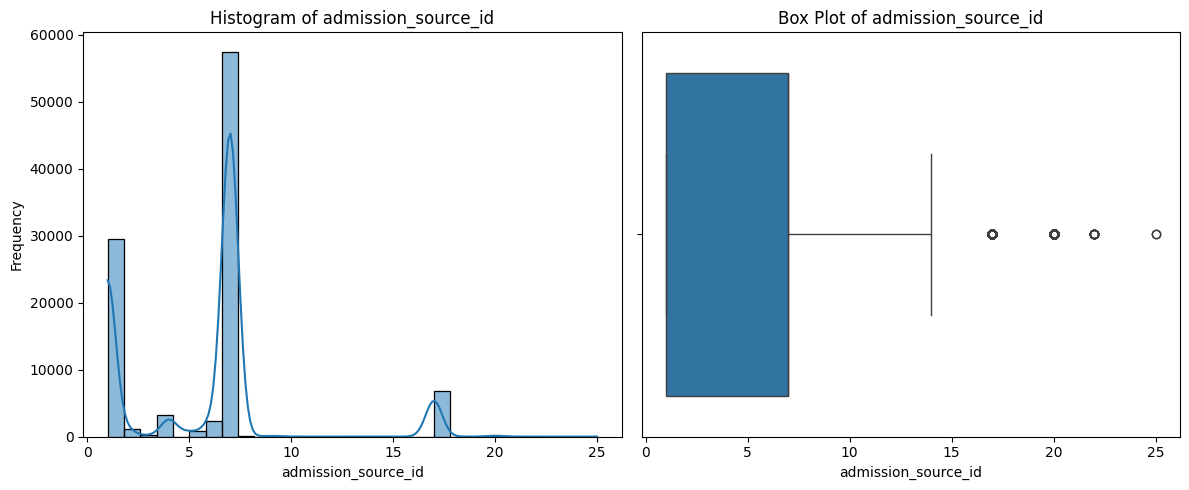

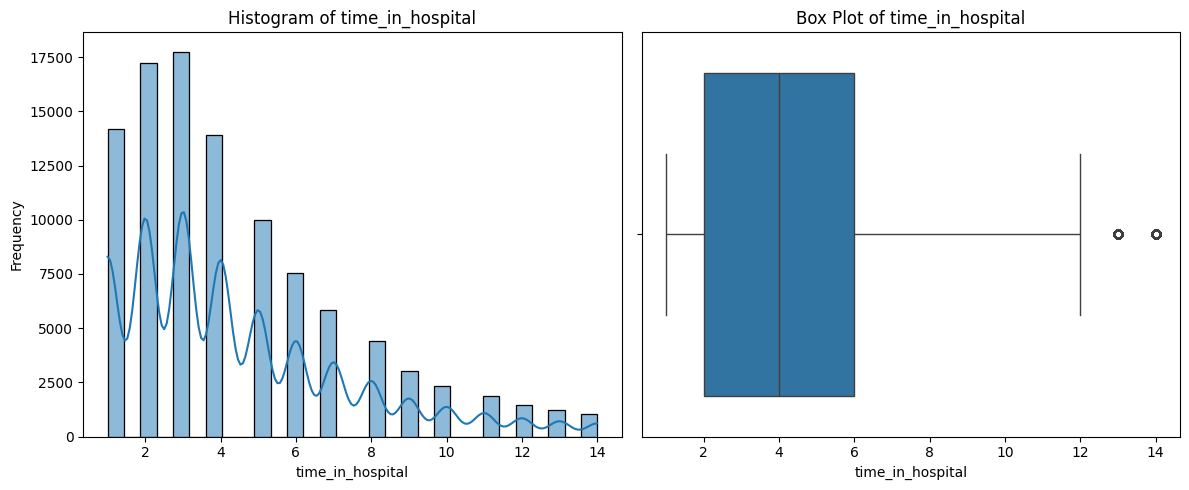

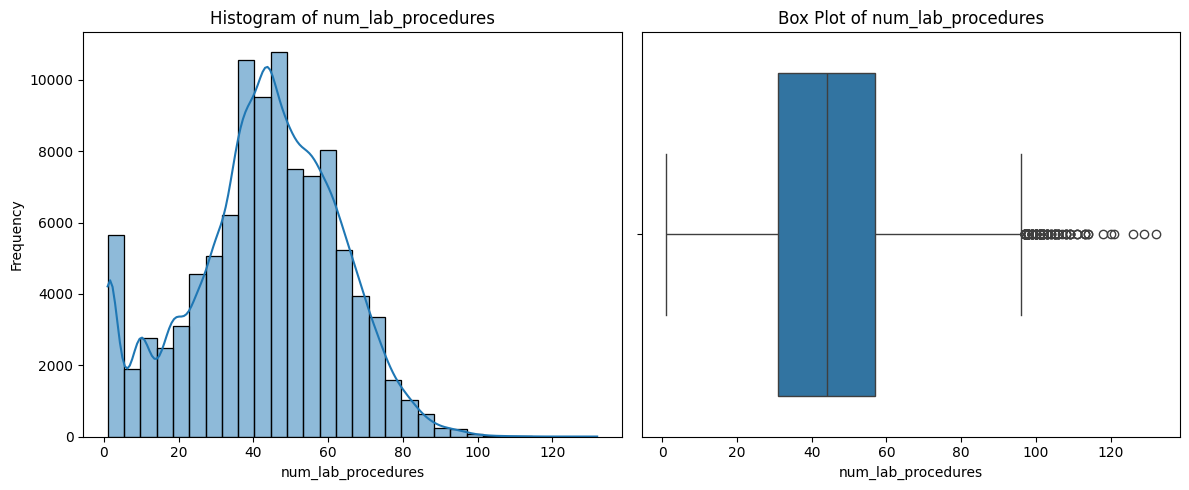

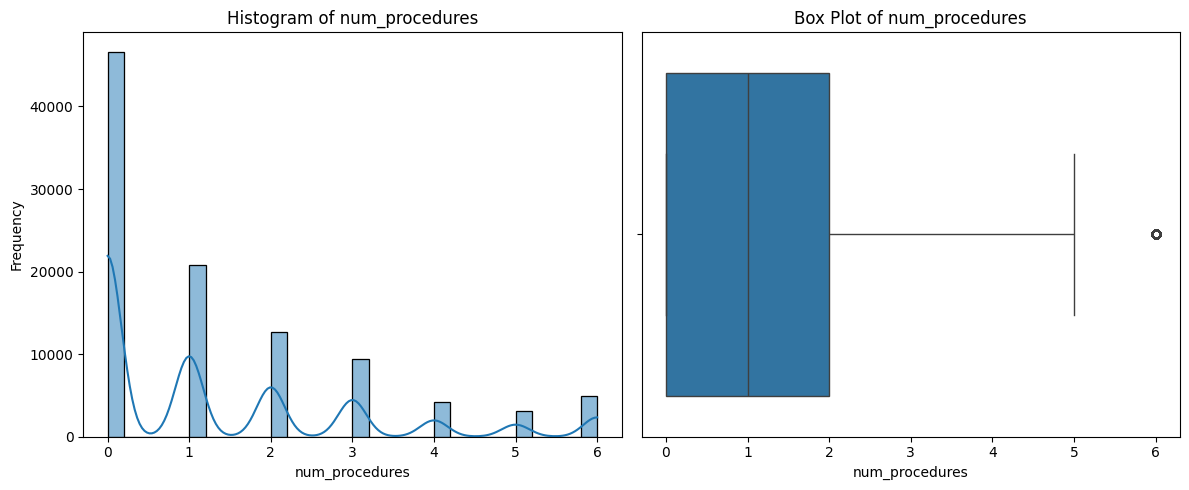

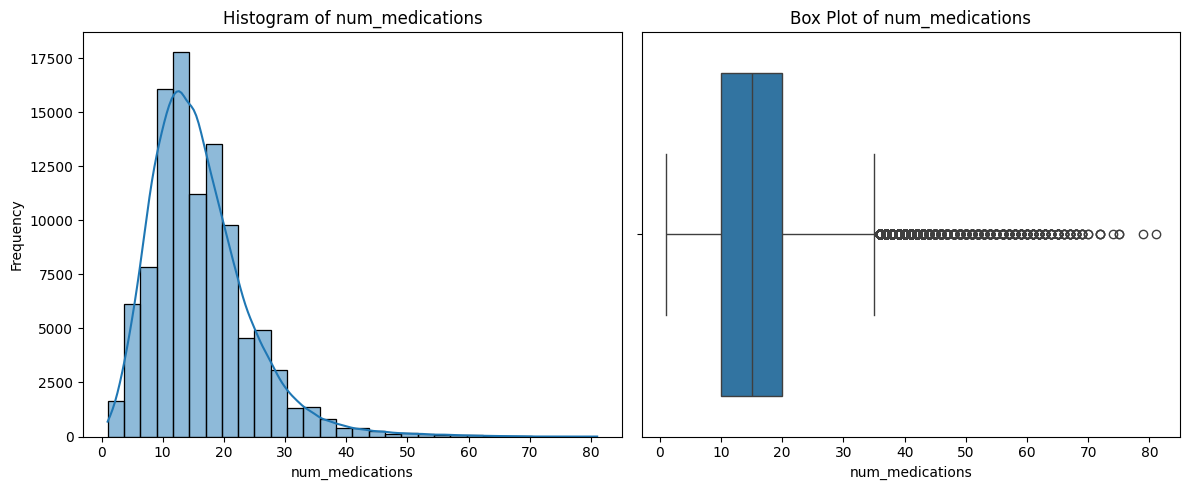

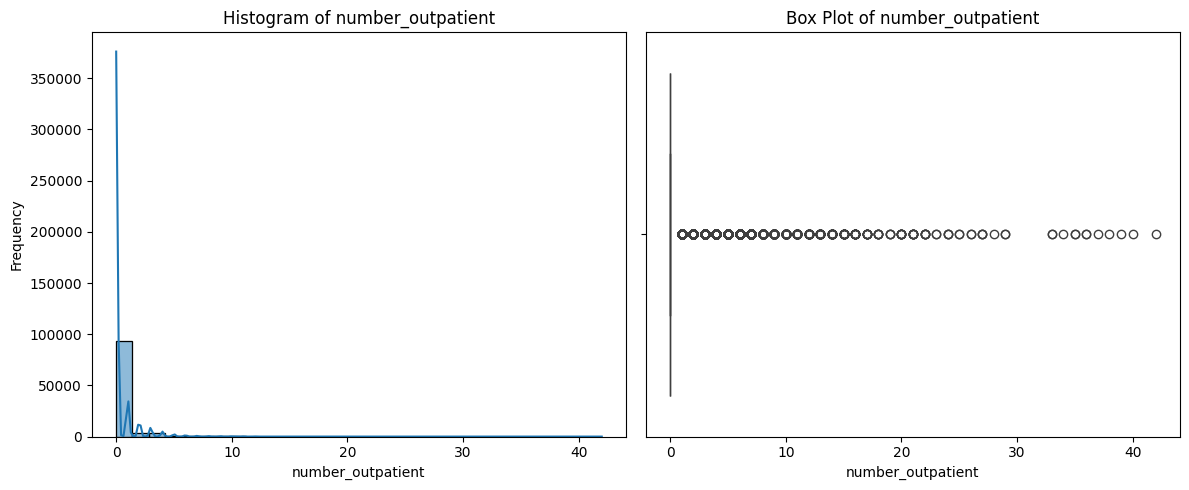

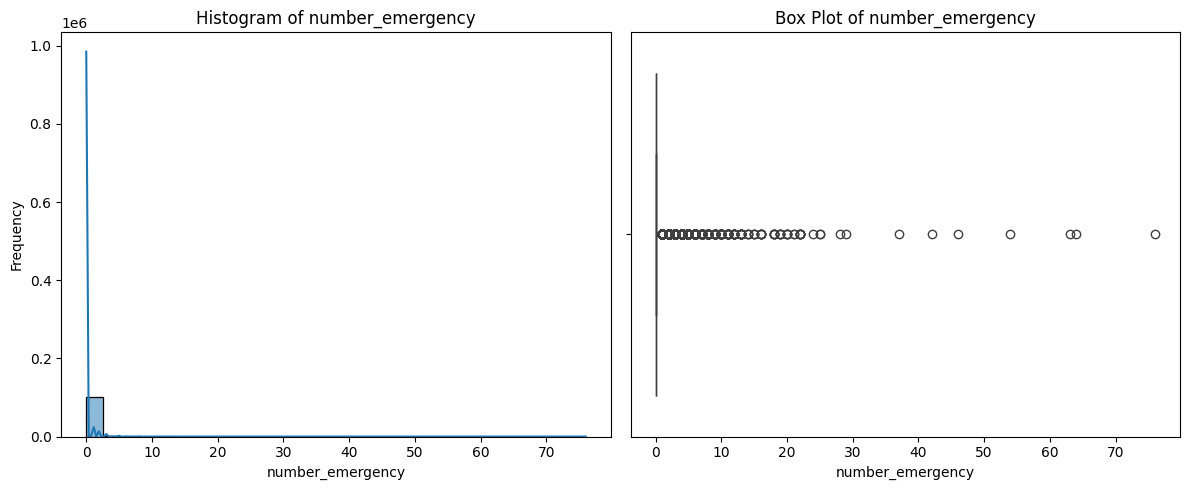

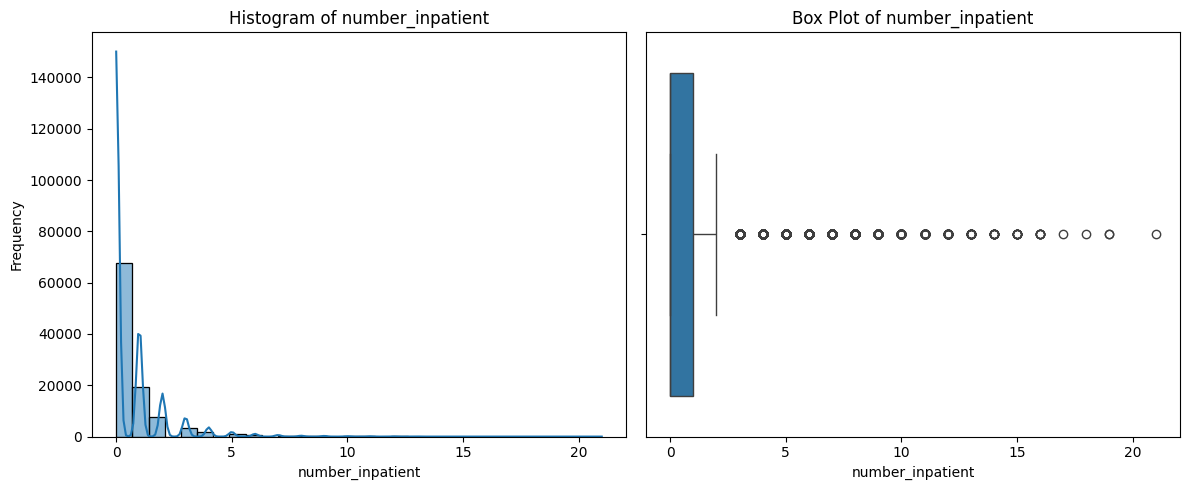

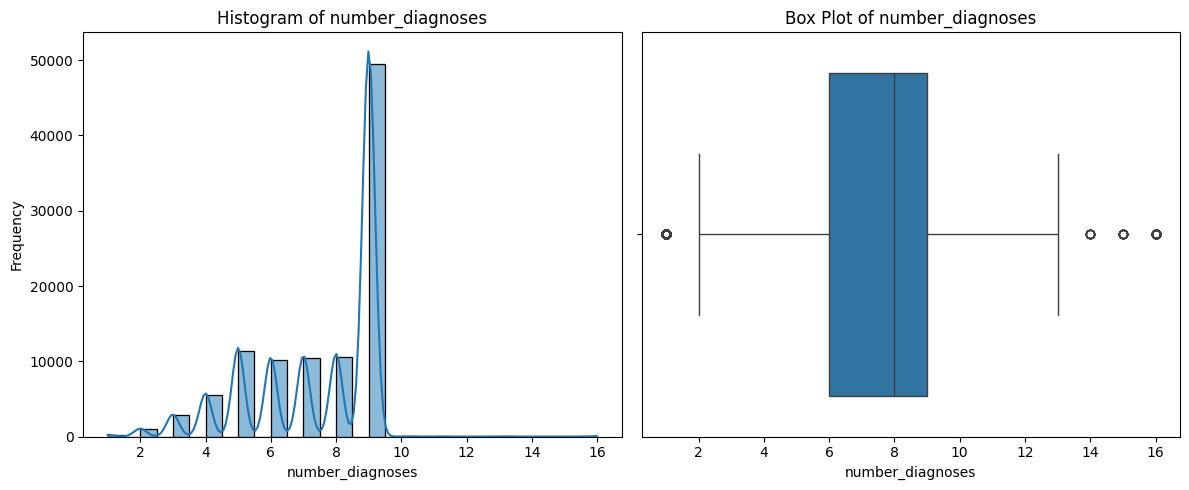

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude 'payer_code' from numerical columns as it has no non-null values
if 'payer_code' in numerical_cols:
    numerical_cols.remove('payer_code')


print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# --- Visualize numerical columns ---
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

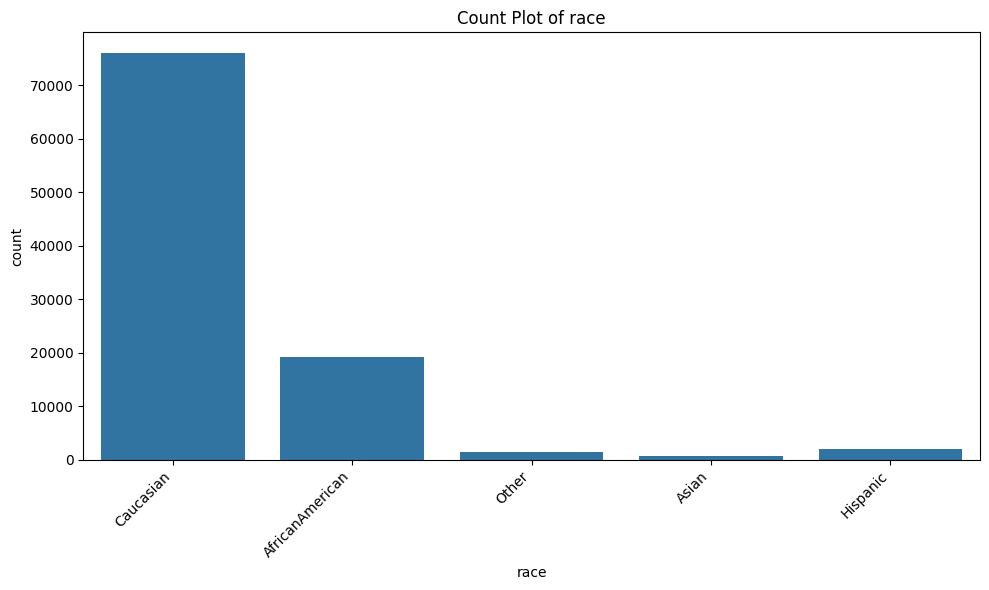

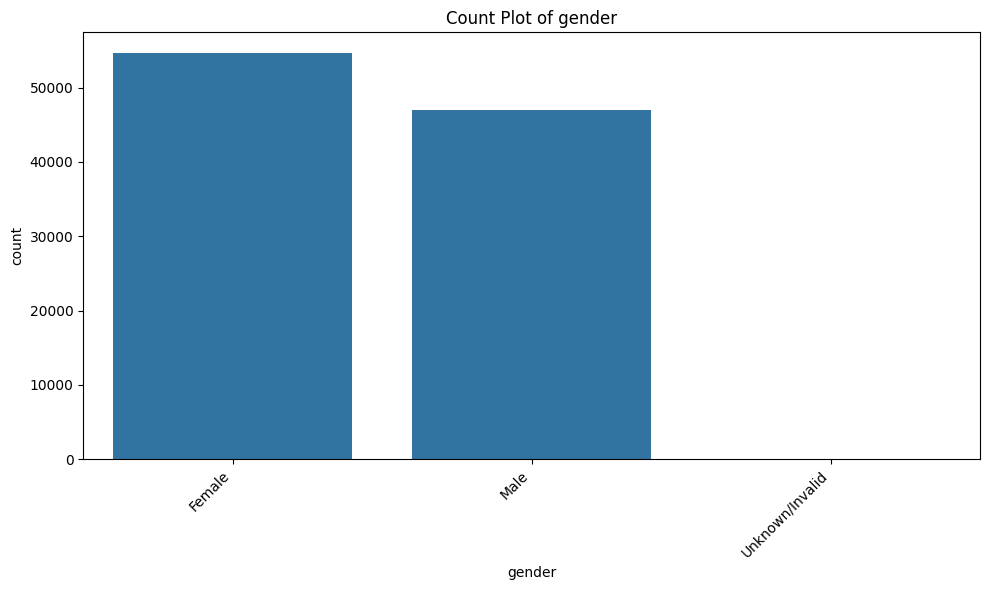

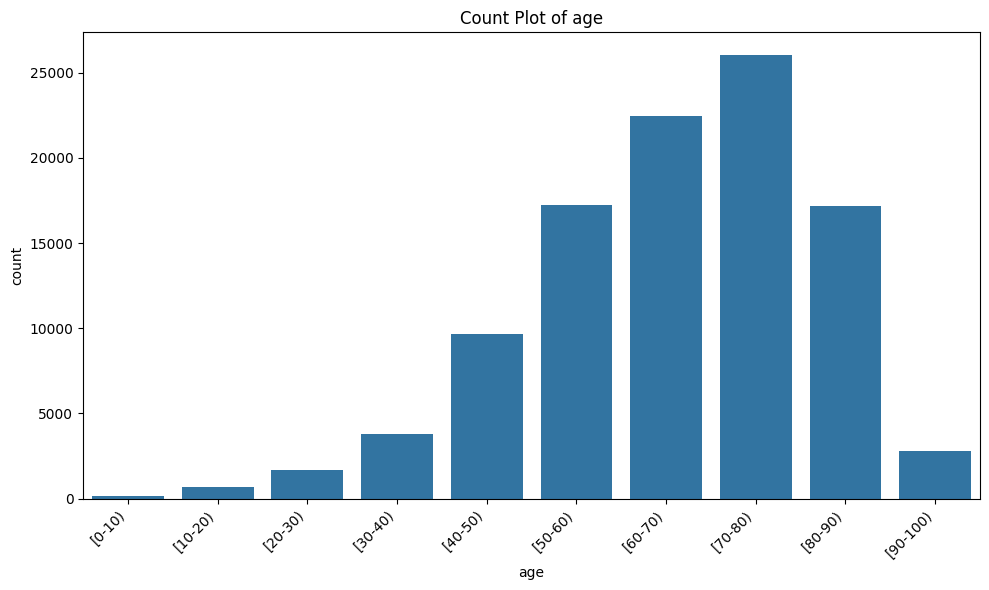

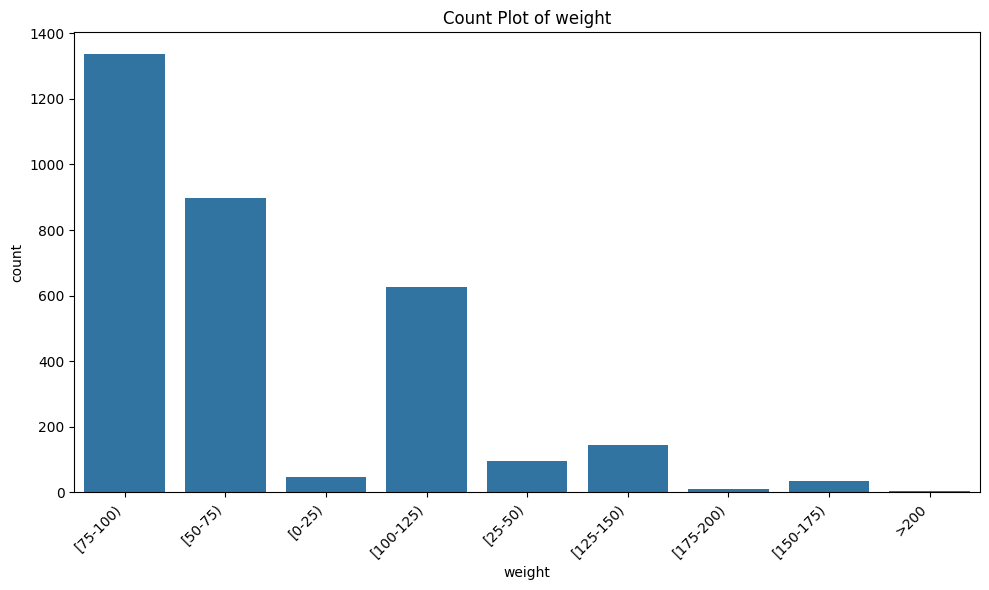

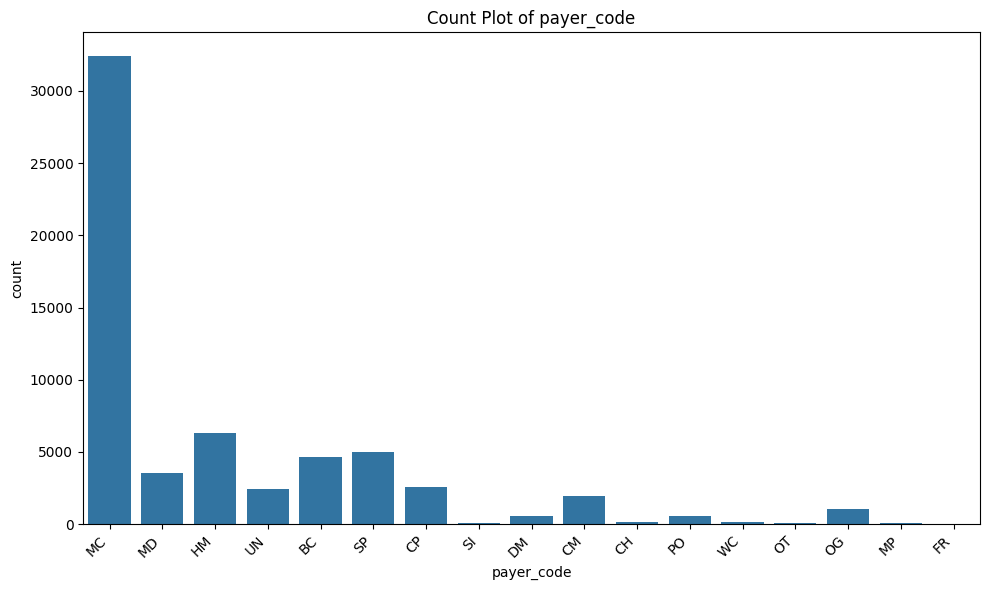

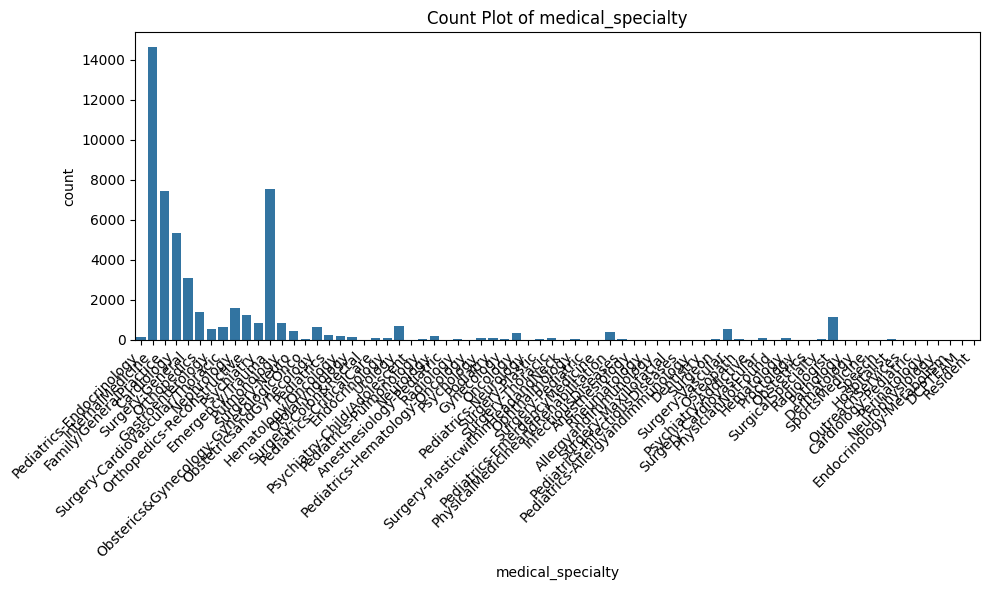

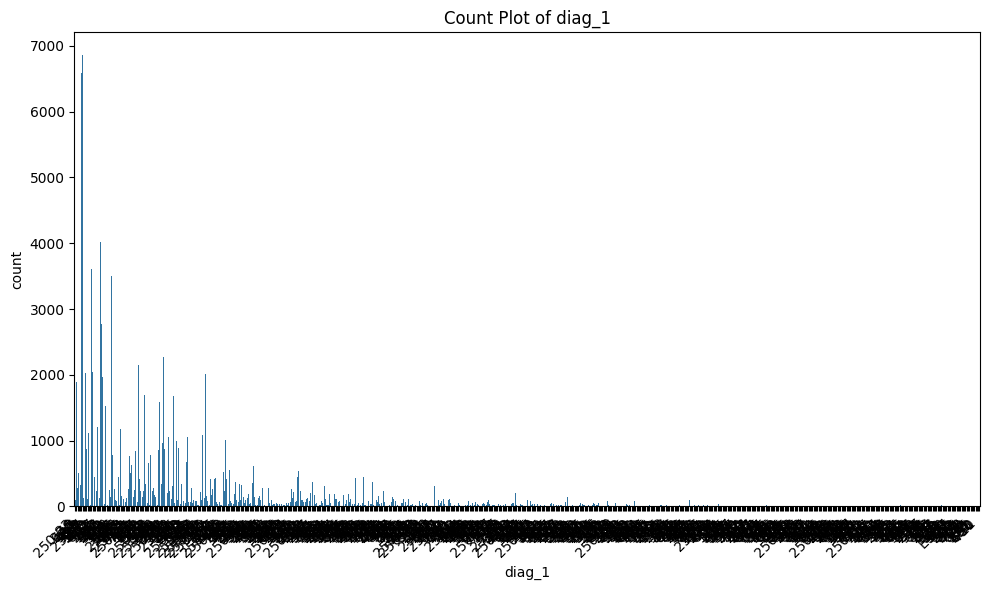

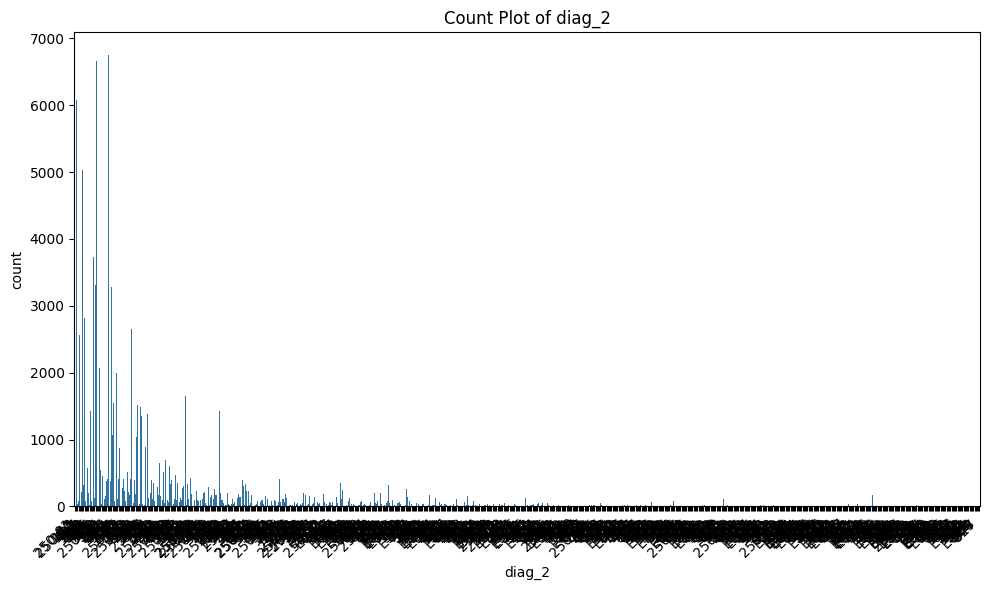

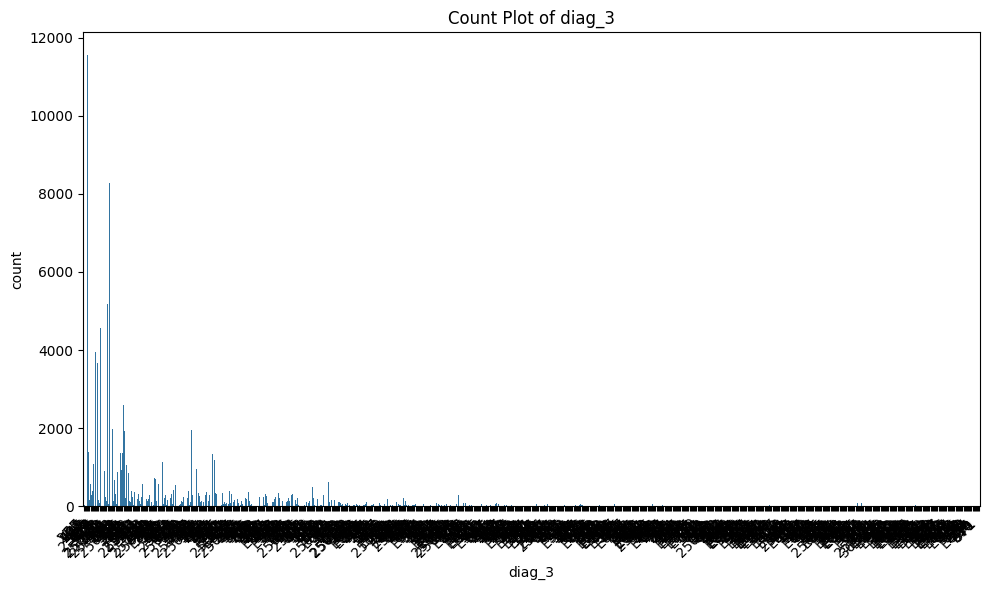

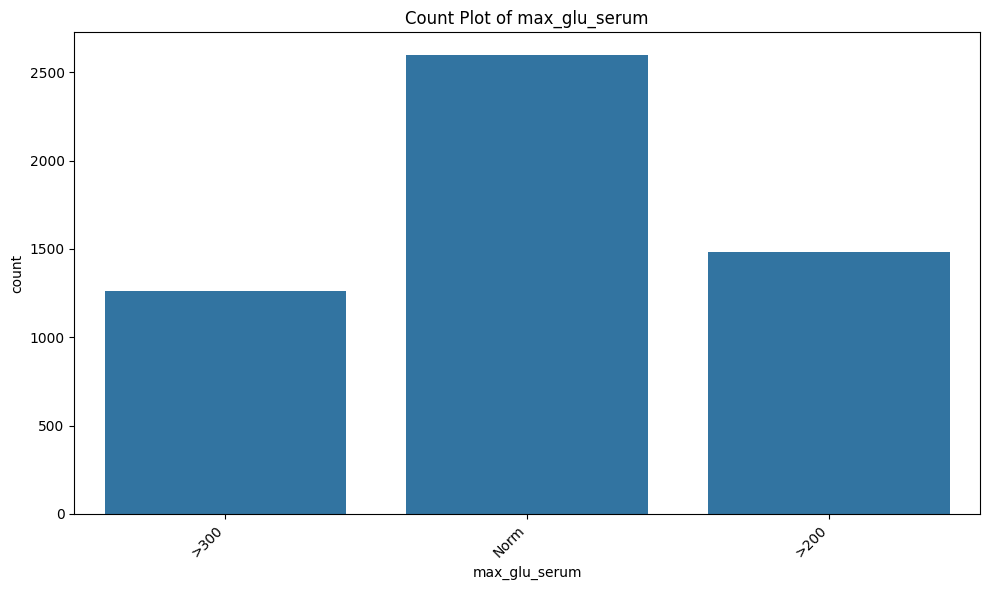

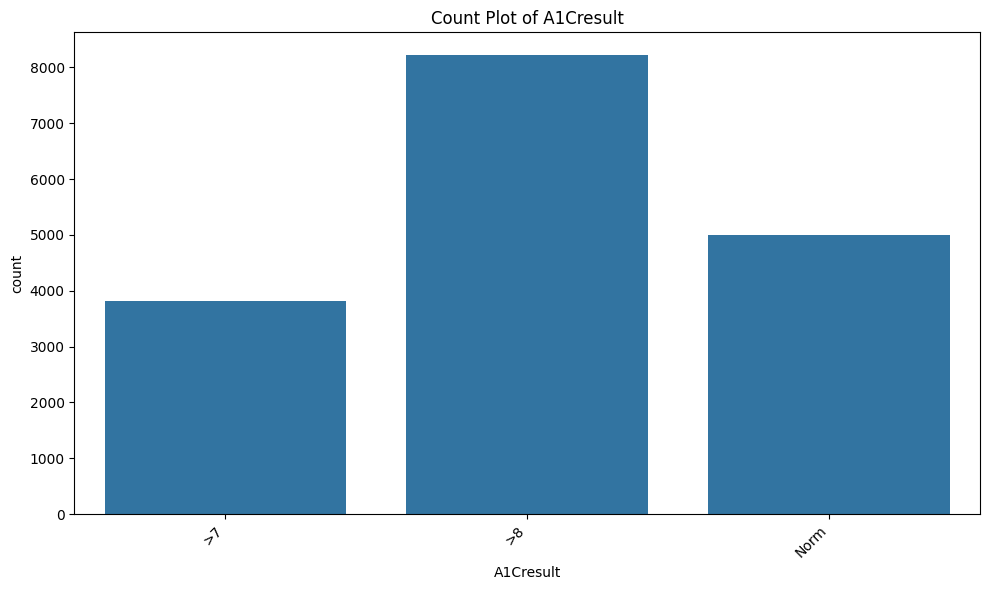

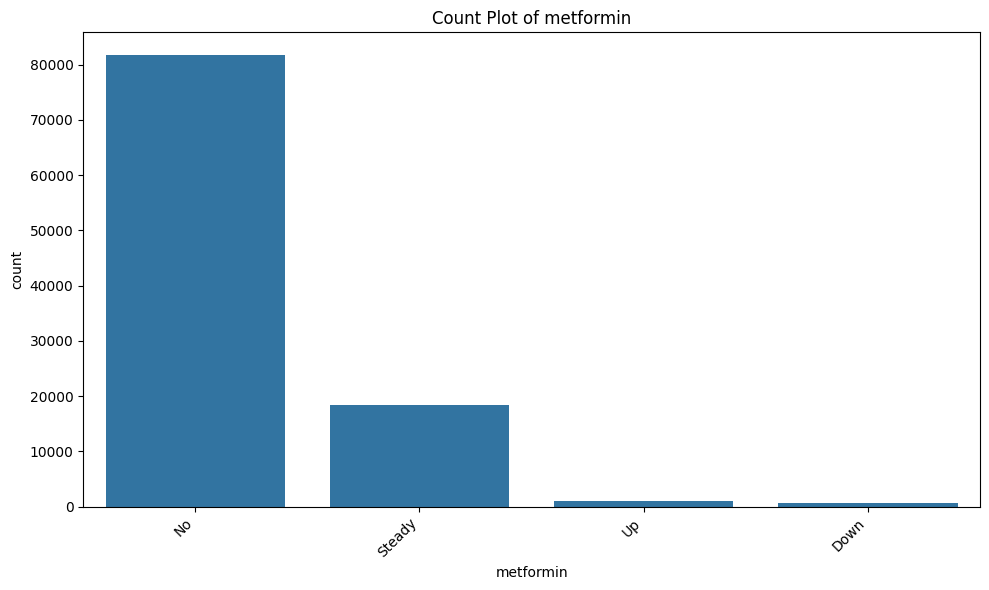

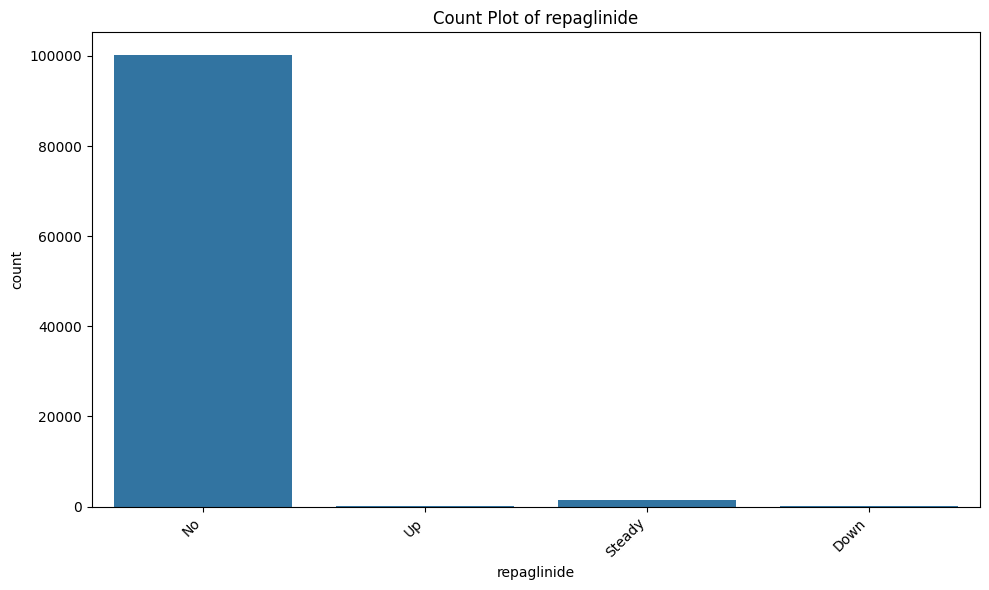

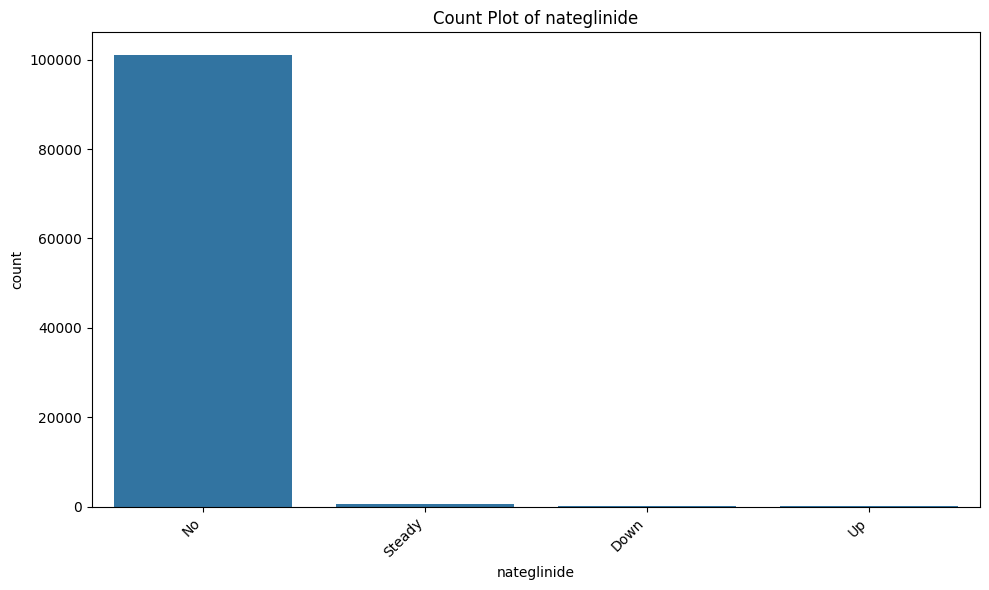

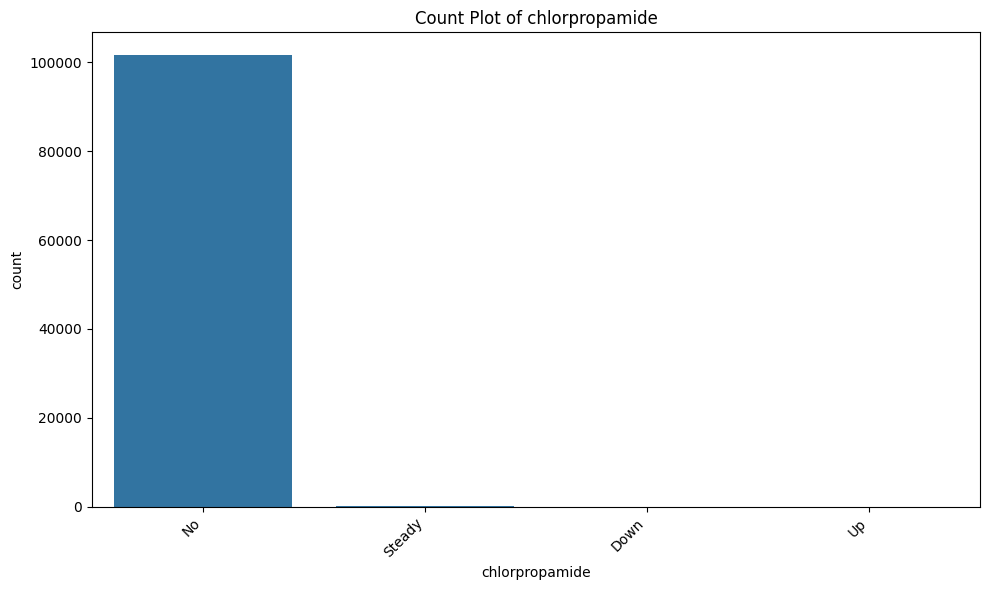

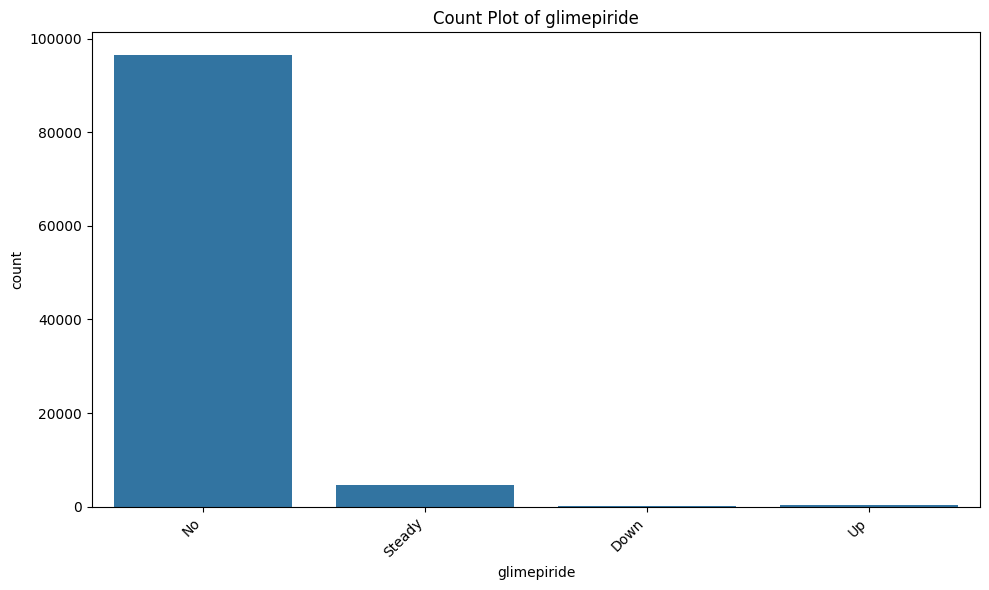

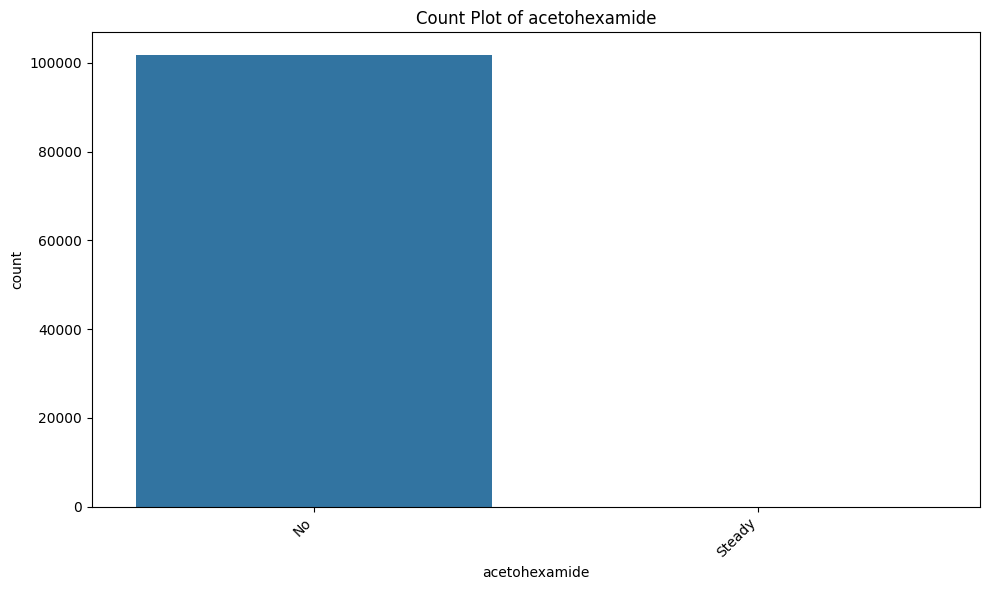

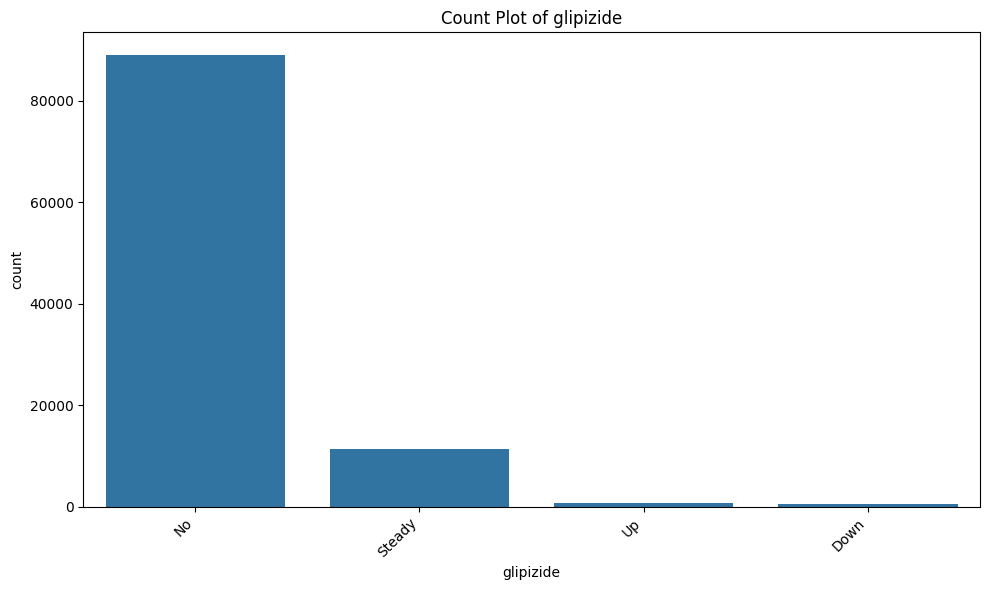

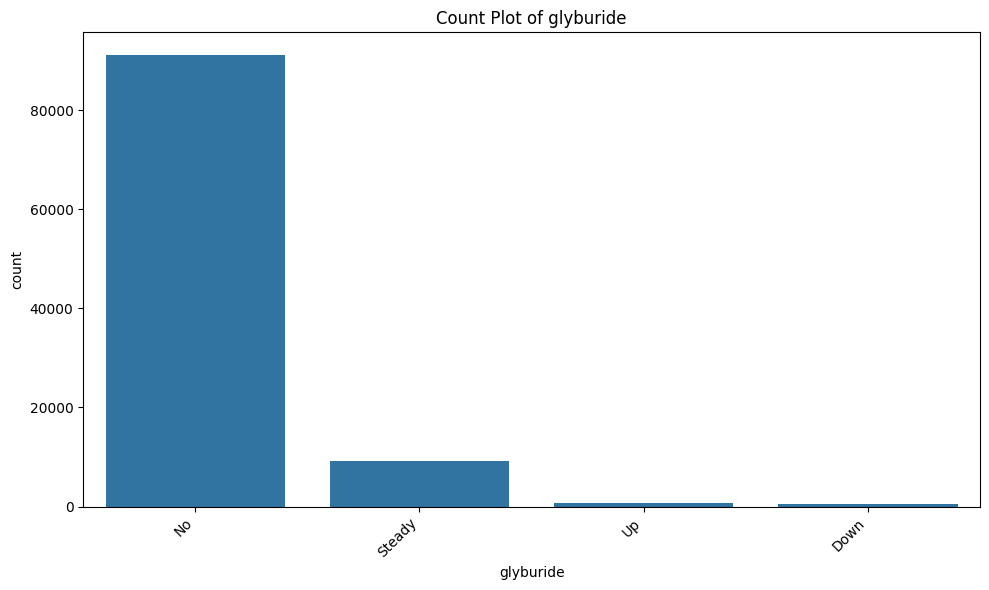

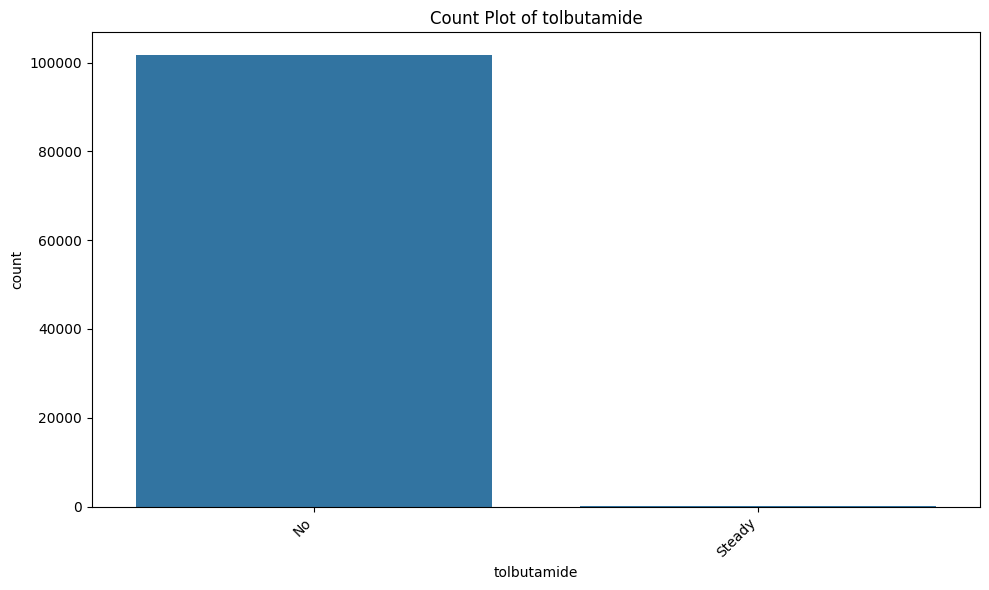

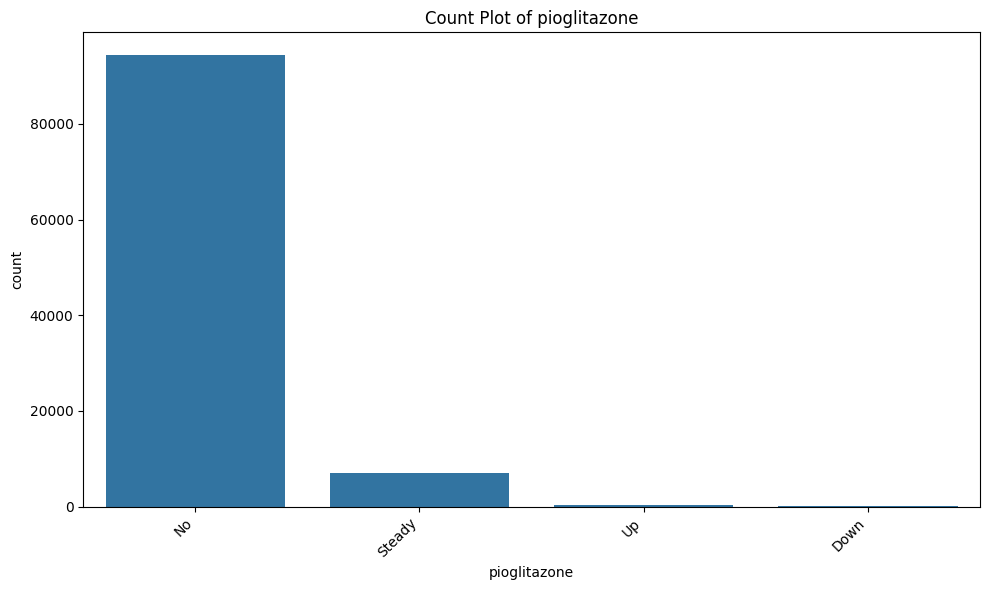

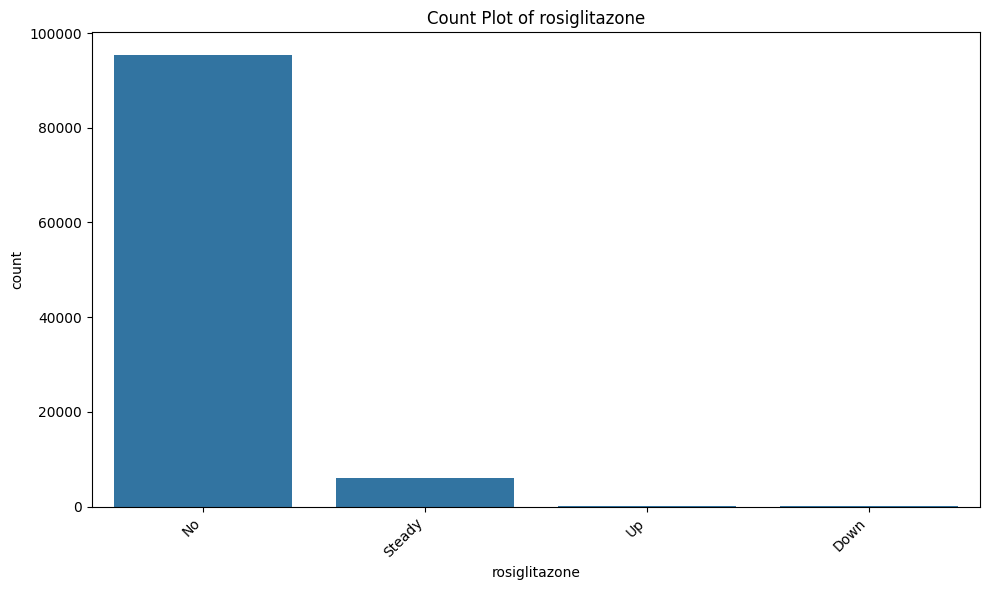

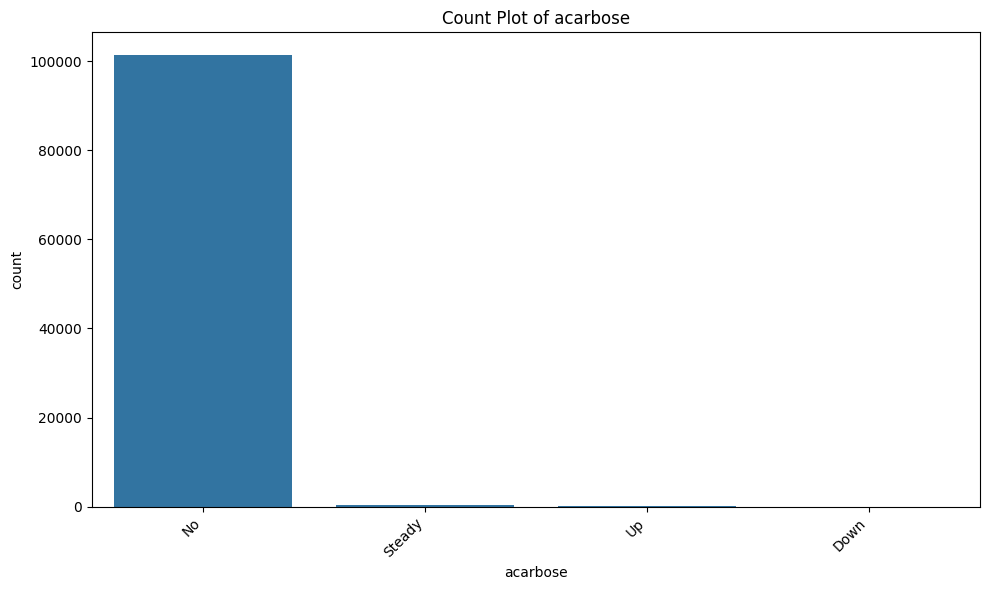

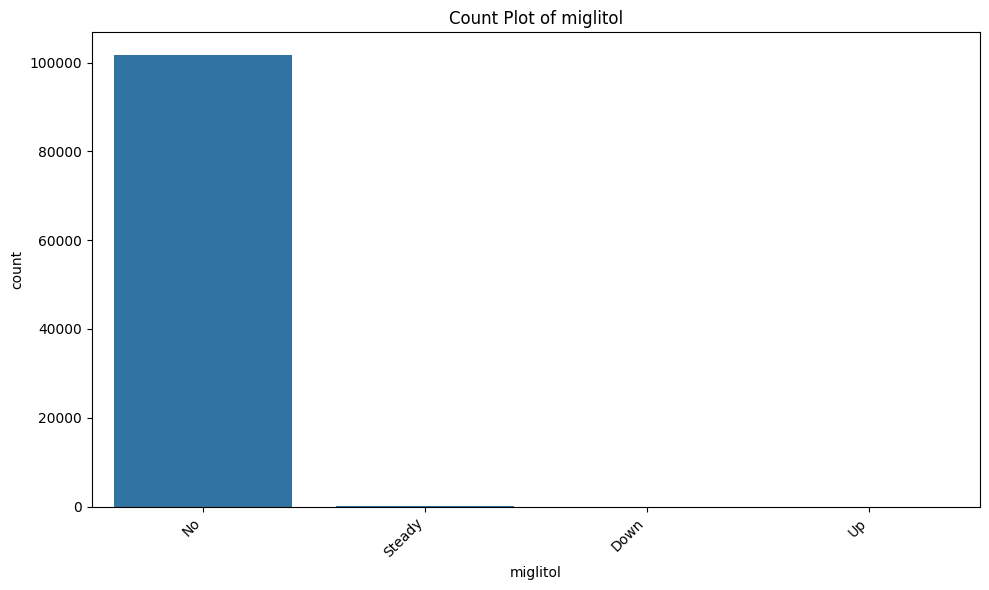

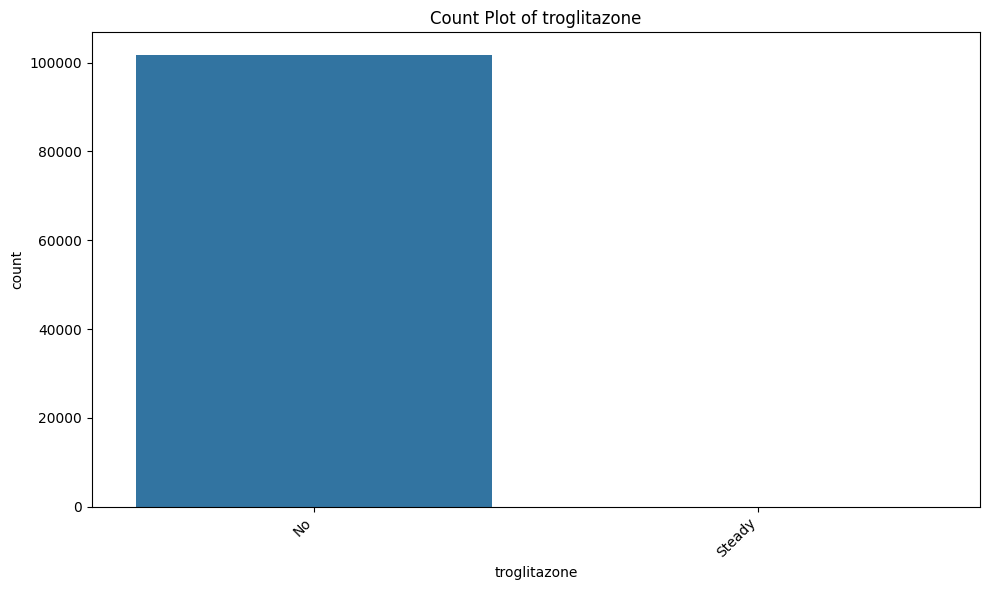

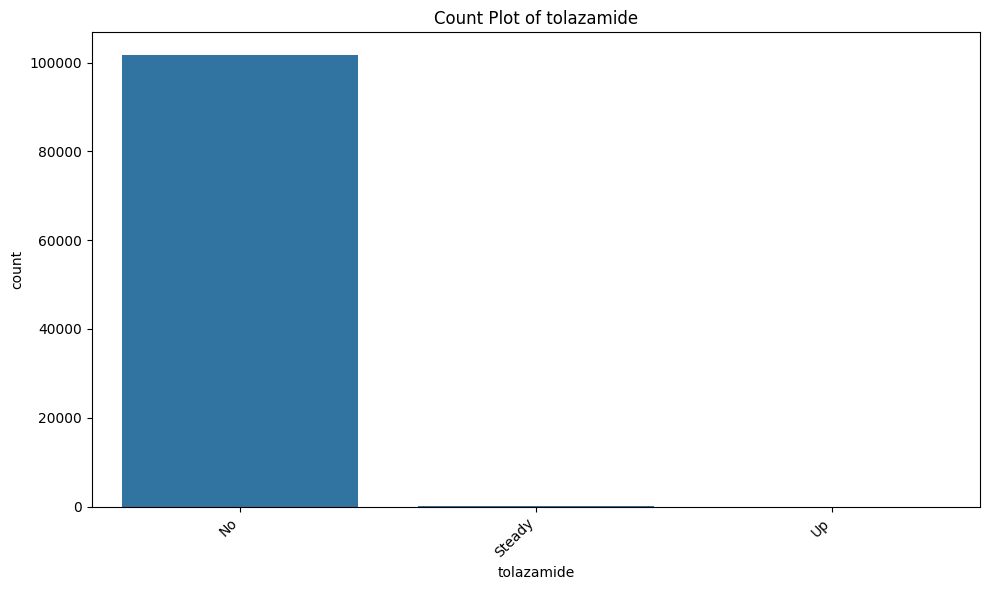

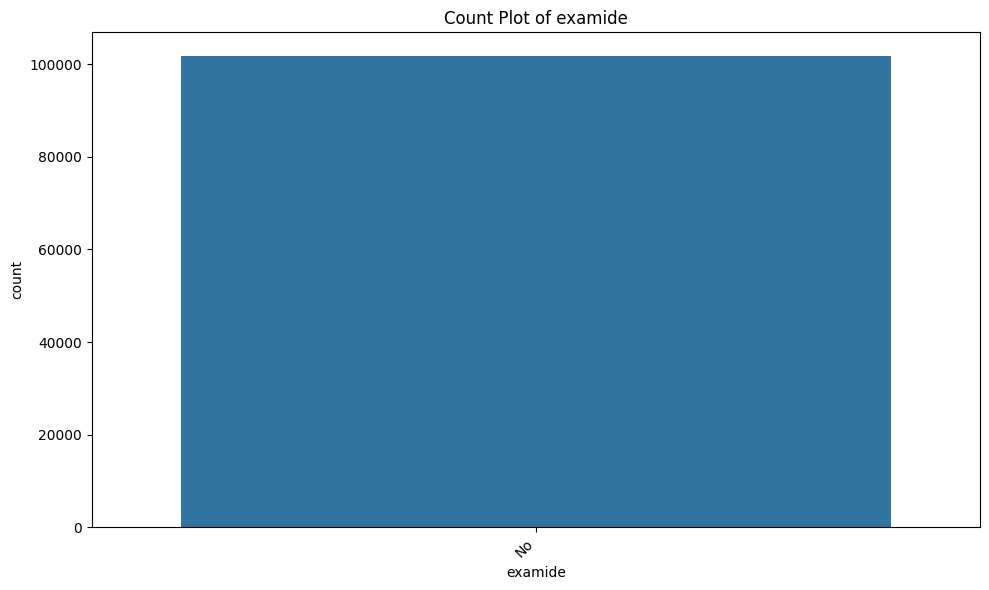

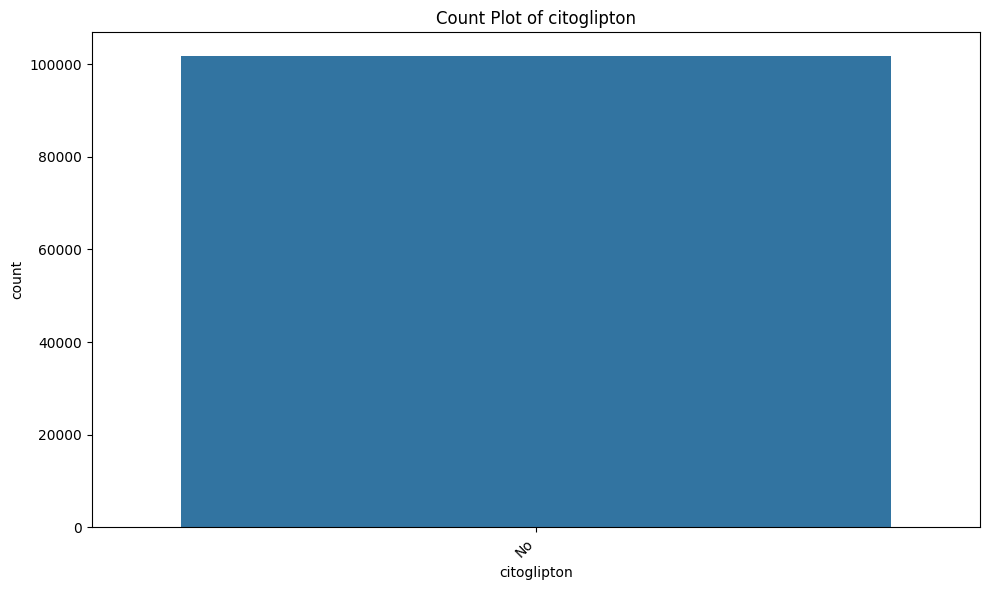

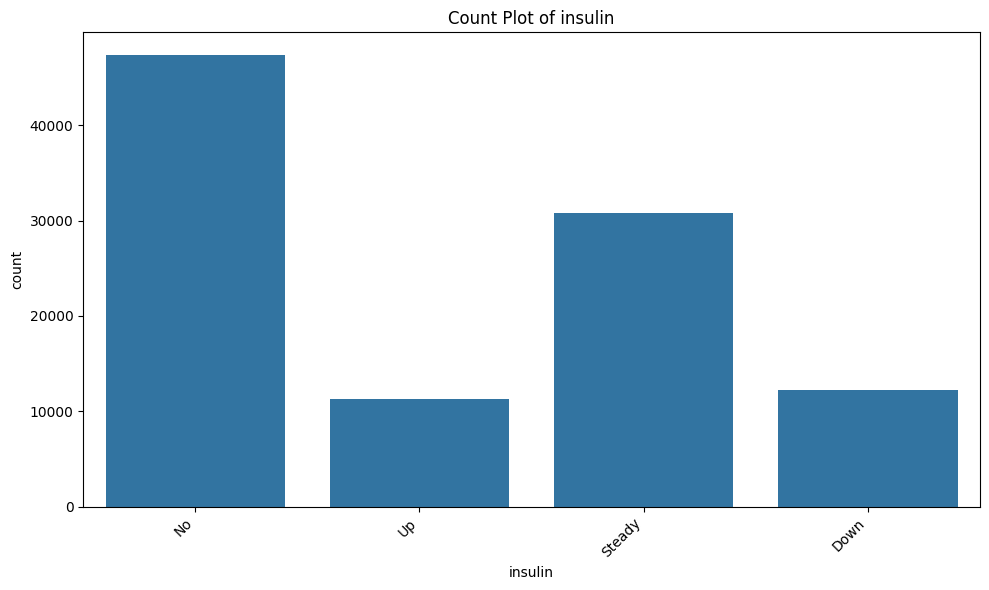

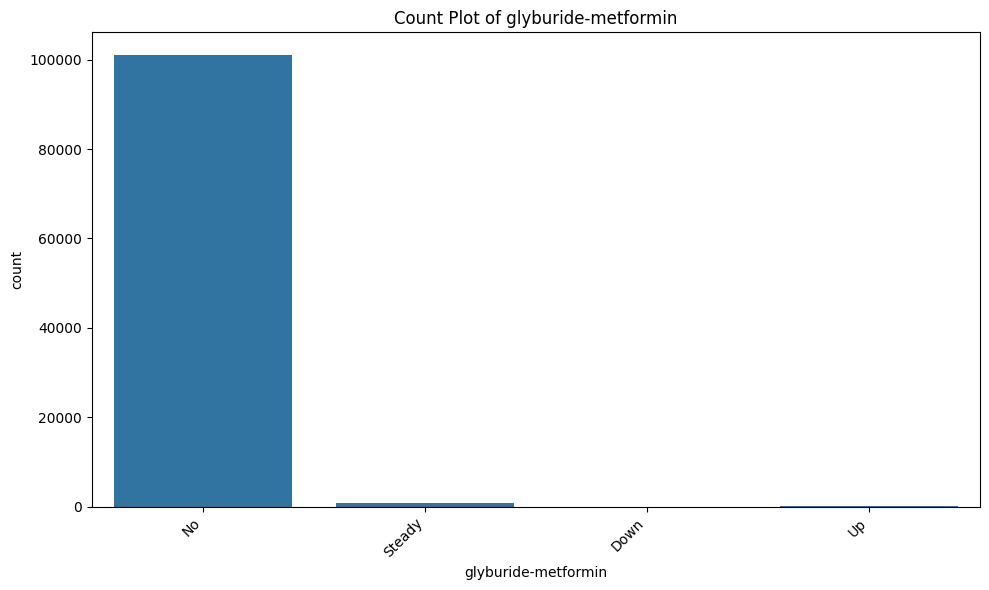

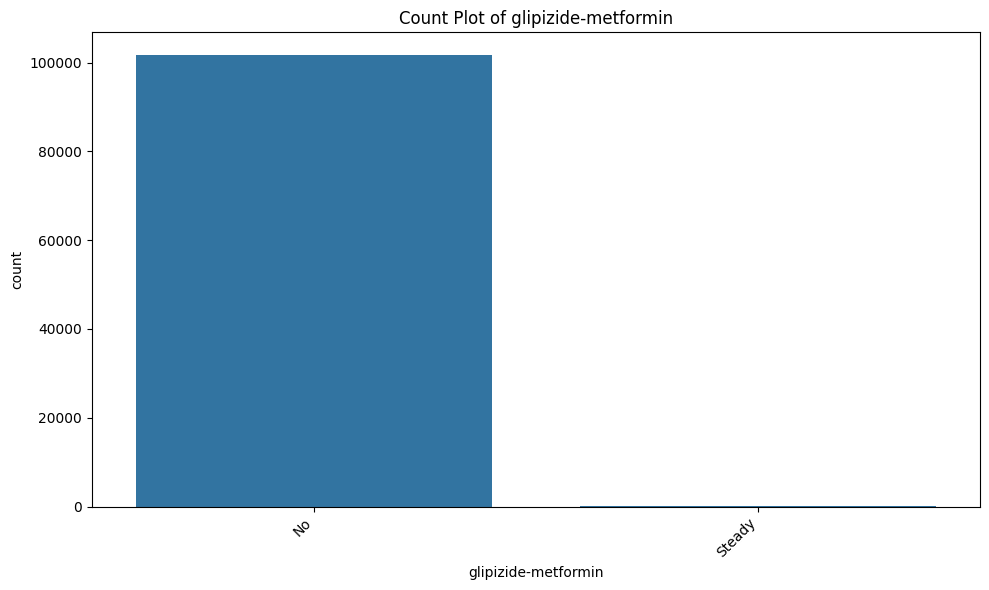

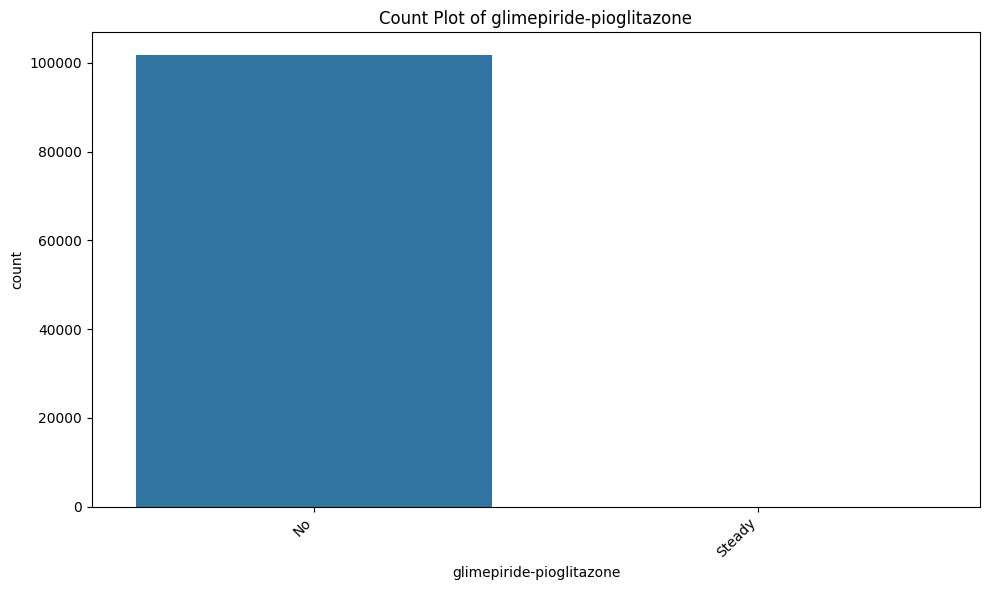

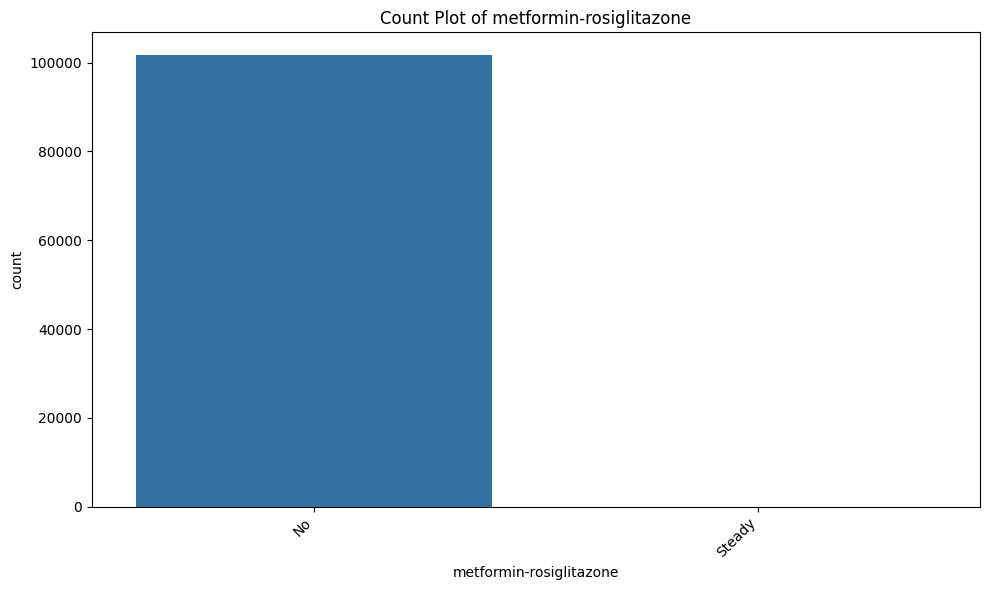

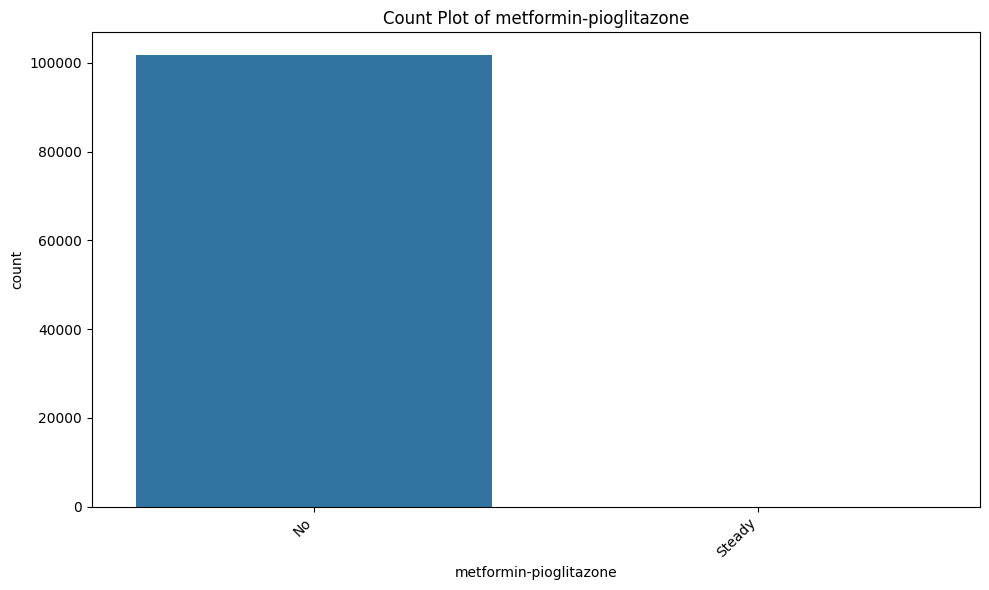

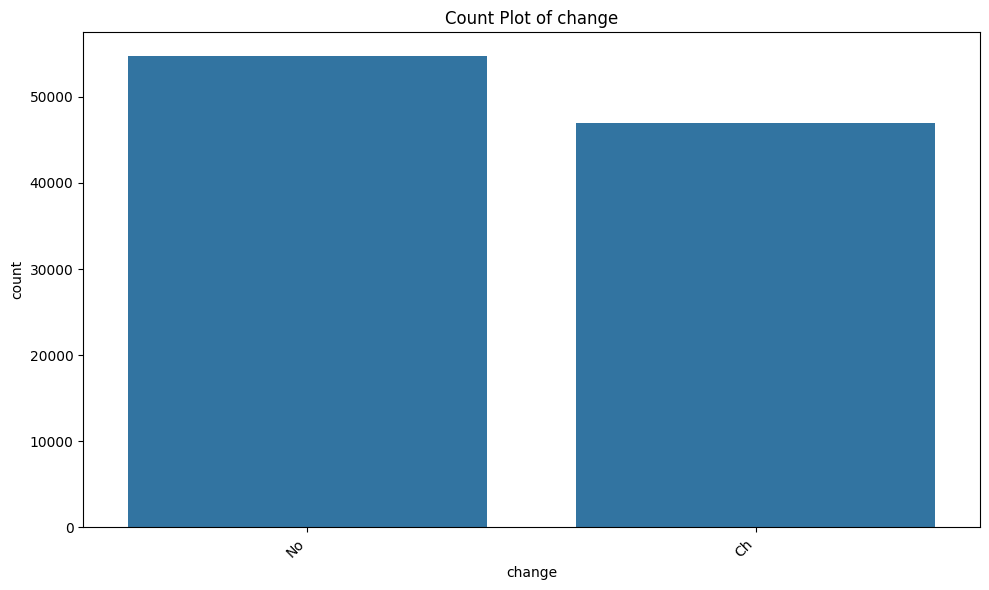

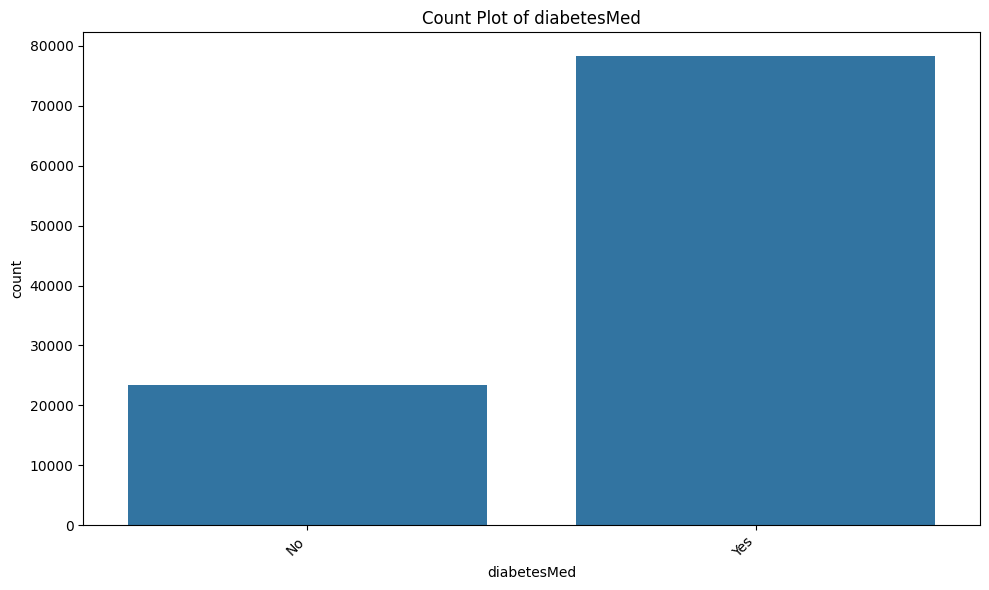

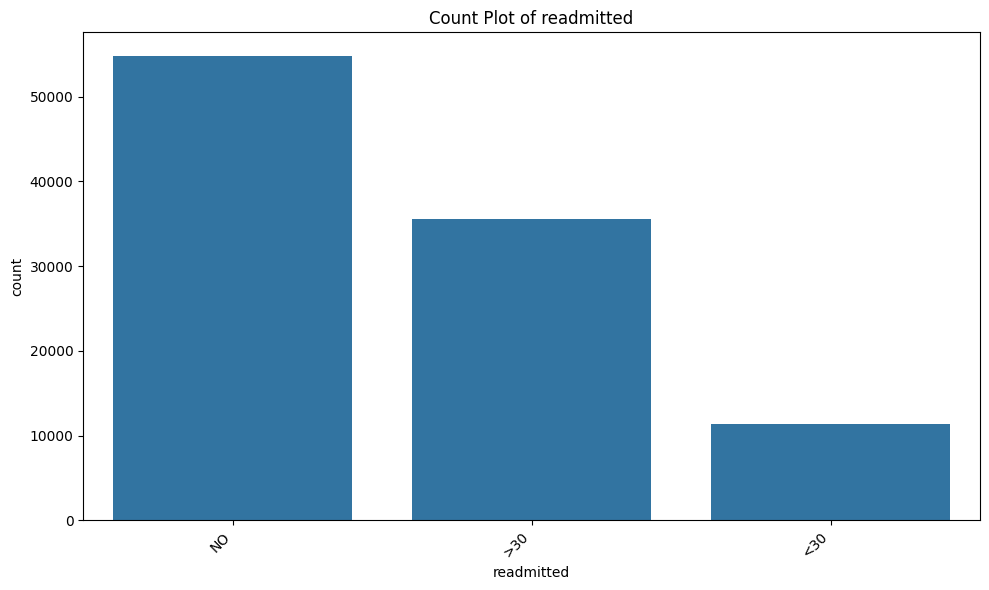

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

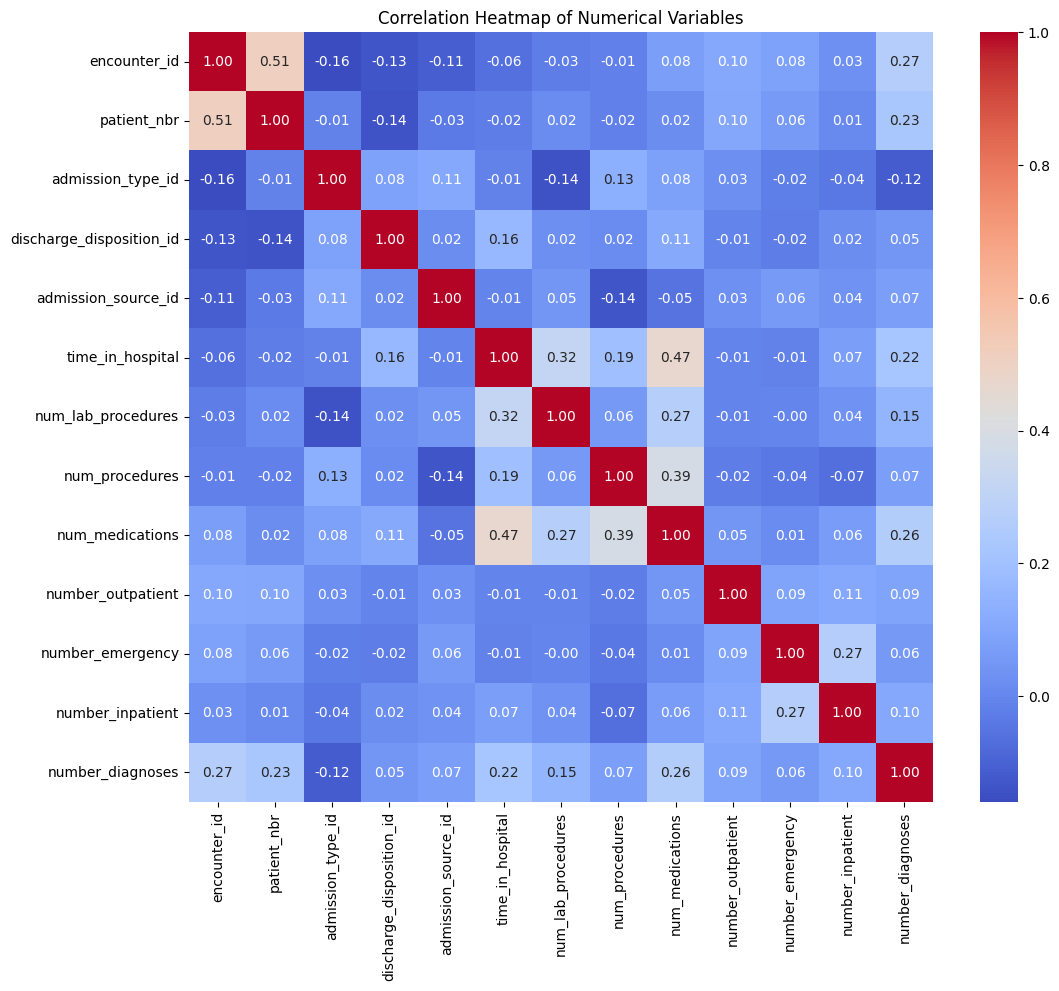

In [ ]:
import numpy as np
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values >= 0])

Missing values per column:


,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
import numpy as np
# Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Drop columns with a high percentage of missing values, like 'payer_code'
if 'payer_code' in cols_with_missing:
    df = df.drop('payer_code', axis=1)
    cols_with_missing.remove('payer_code') # Remove from the list of columns to impute


# Impute missing values with the mode for the remaining columns
for col in cols_with_missing:
    # Check if the mode exists before imputing
    if not df[col].mode().empty:
        mode_val = df[col].mode()[0]  # Calculate the mode (mode() returns a Series)
        df[col].fillna(mode_val, inplace=True)
    else:
        # Optionally, handle columns where mode is empty (e.g., drop or use another imputation method)
        print(f"Warning: Mode is empty for column '{col}'. Skipping imputation for this column.")


# Verify that there are no more missing values in the imputed columns
print("Missing values after imputation:")
display(df.isnull().sum())

/tmp/ipython-input-4167862960.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Missing values after imputation:


,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
medication_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df['on_any_medication'] = df[medication_columns].apply(lambda x: 1 if (x != 'No').any() else 0, axis=1)

display(df[['on_any_medication'] + medication_columns].head())

,on_any_medication,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,...,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone
0,0,No,No,No,No,No,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No
1,1,No,No,No,No,No,No,No,No,No,...,No,No,No,No,Up,No,No,No,No,No
2,1,No,No,No,No,No,No,Steady,No,No,...,No,No,No,No,No,No,No,No,No,No
3,1,No,No,No,No,No,No,No,No,No,...,No,No,No,No,Up,No,No,No,No,No
4,1,No,No,No,No,No,No,Steady,No,No,...,No,No,No,No,Steady,No,No,No,No,No


In [ ]:
selected_columns = [
    'race', 'gender', 'age', 'weight', 'time_in_hospital',
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
    'on_any_medication'
]

df_selected = df[selected_columns]

display(df_selected.head())

,race,gender,age,weight,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,readmitted,on_any_medication
0,Caucasian,Female,[0-10),[75-100),1,41,0,1,0,0,0,1,No,No,NO,0
1,Caucasian,Female,[10-20),[75-100),3,59,0,18,0,0,0,9,Ch,Yes,>30,1
2,AfricanAmerican,Female,[20-30),[75-100),2,11,5,13,2,0,1,6,No,Yes,NO,1
3,Caucasian,Male,[30-40),[75-100),2,44,1,16,0,0,0,7,Ch,Yes,NO,1
4,Caucasian,Male,[40-50),[75-100),1,51,0,8,0,0,0,5,Ch,Yes,NO,1


Numerical columns:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'on_any_medication']

Categorical columns:
['race', 'gender', 'age', 'weight', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


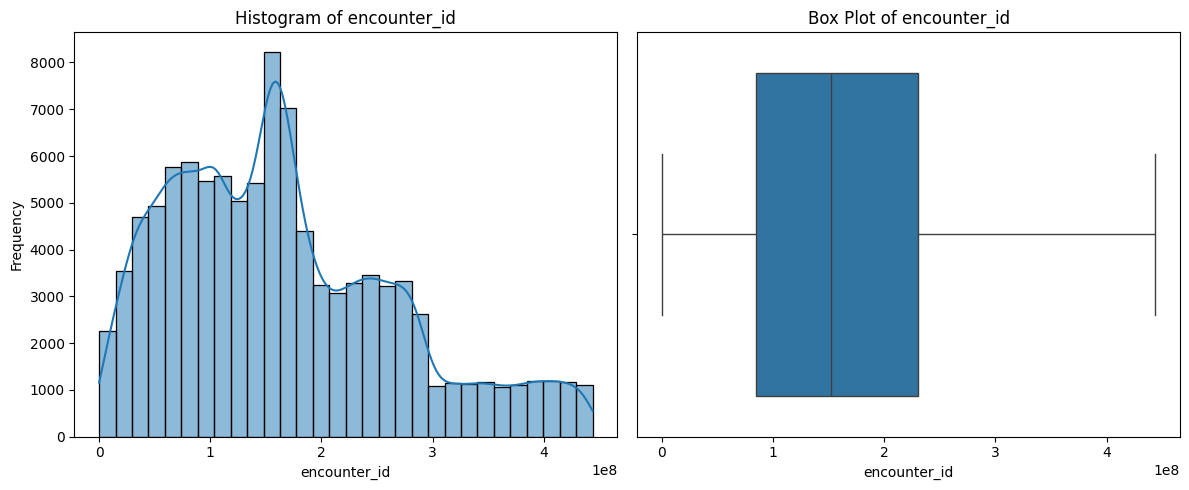

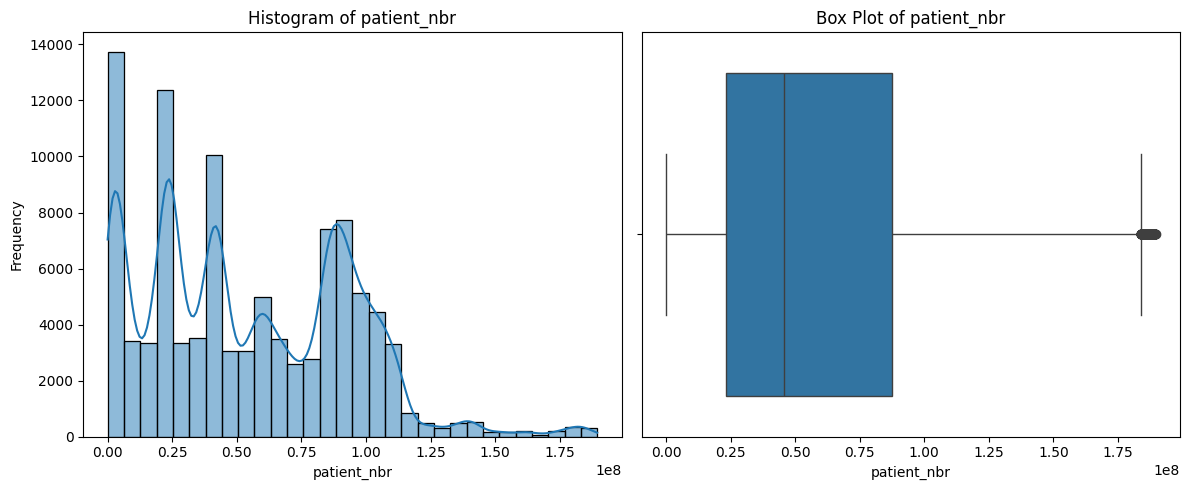

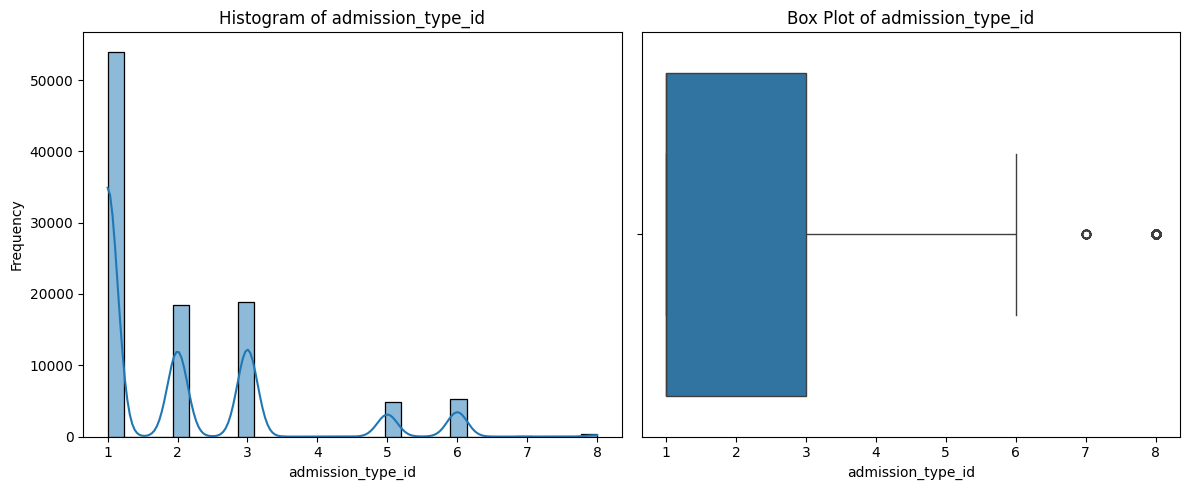

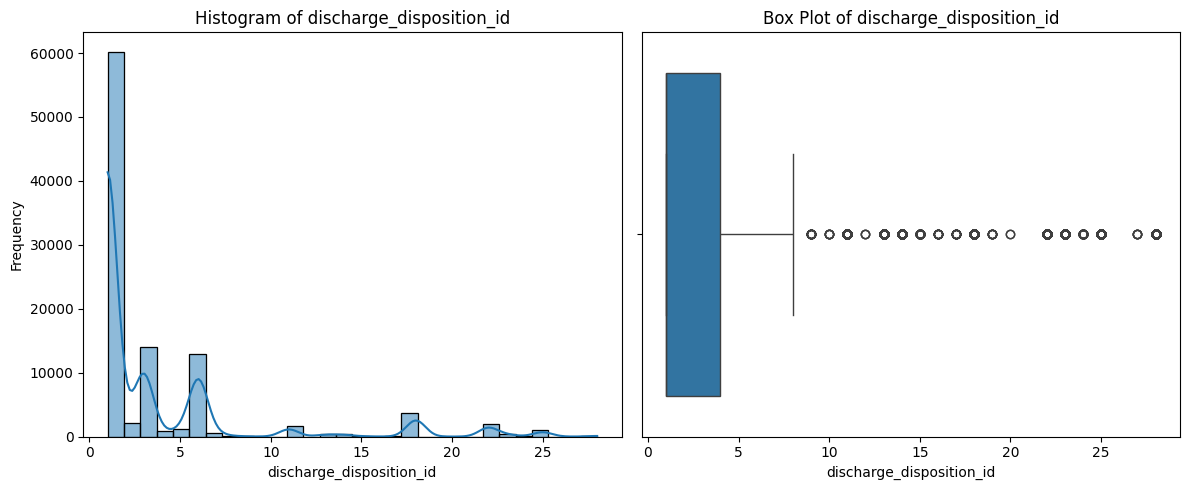

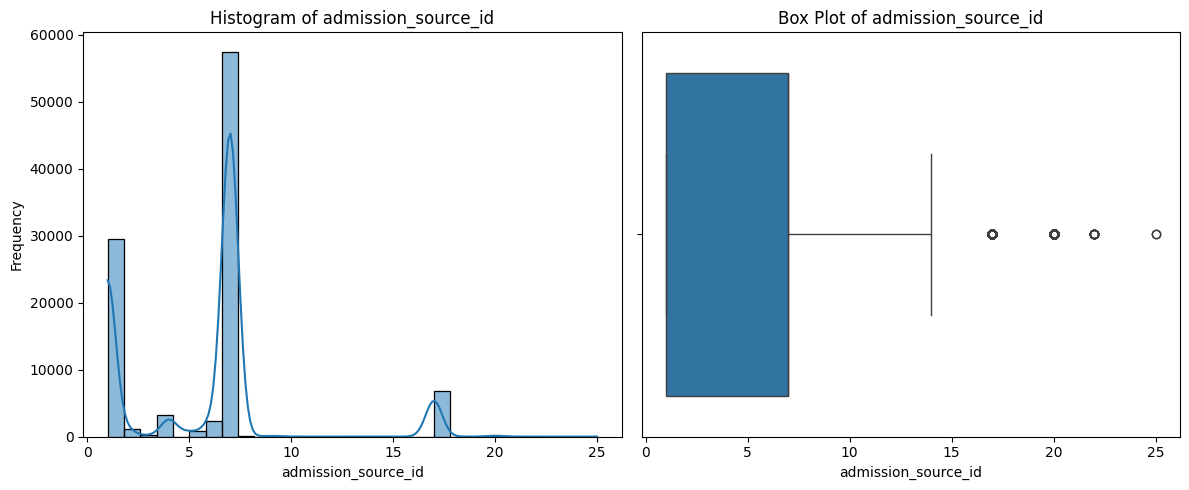

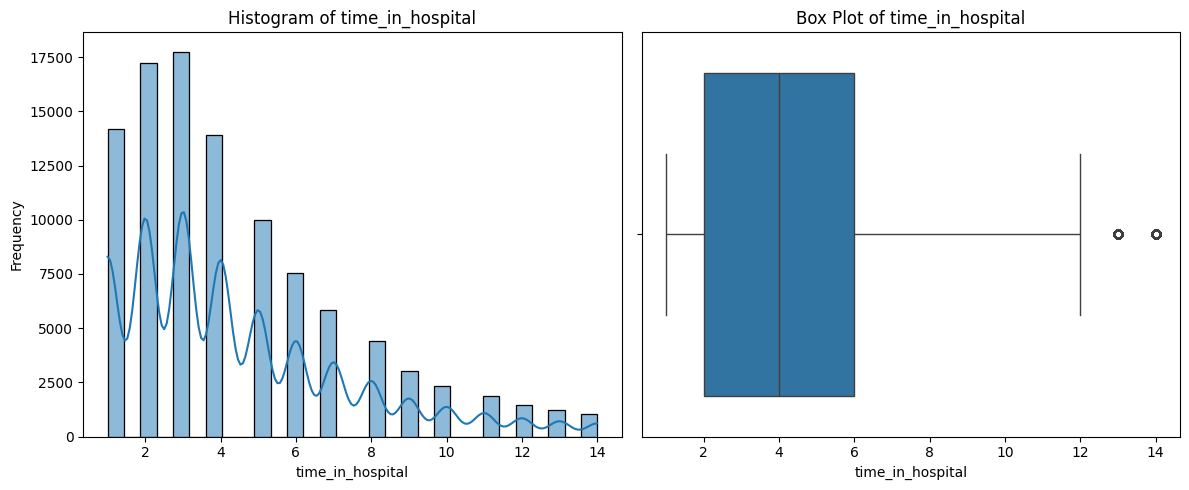

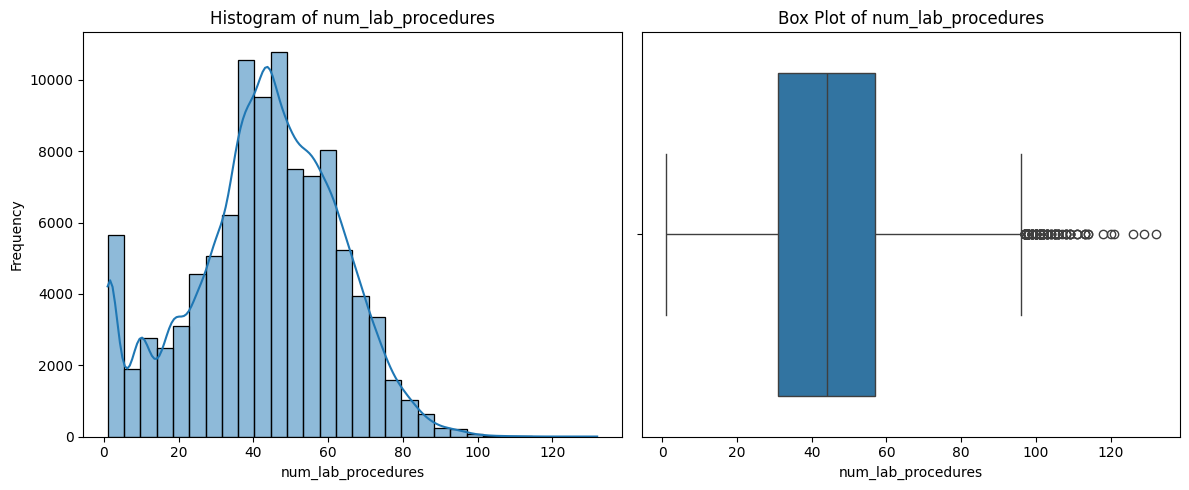

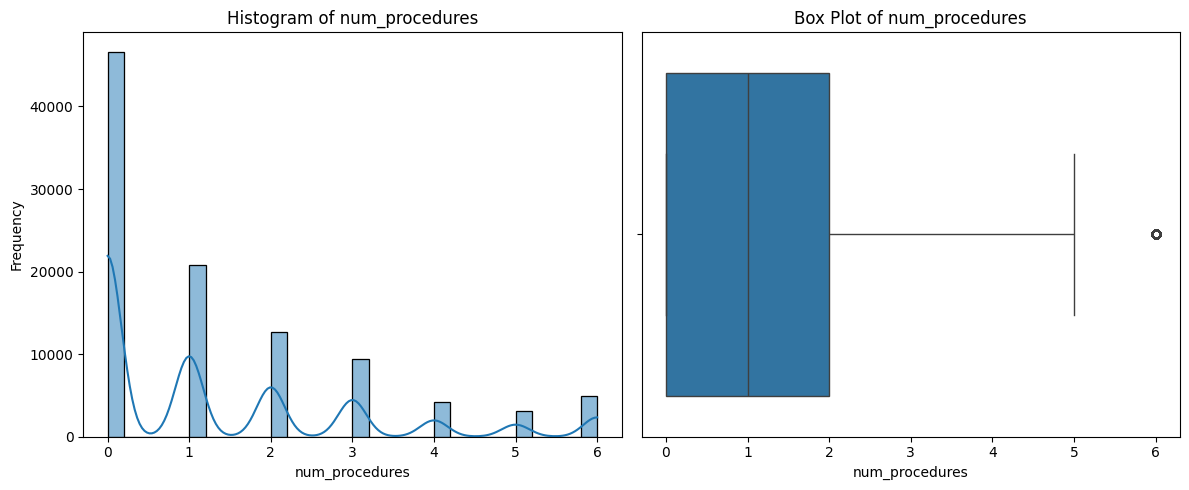

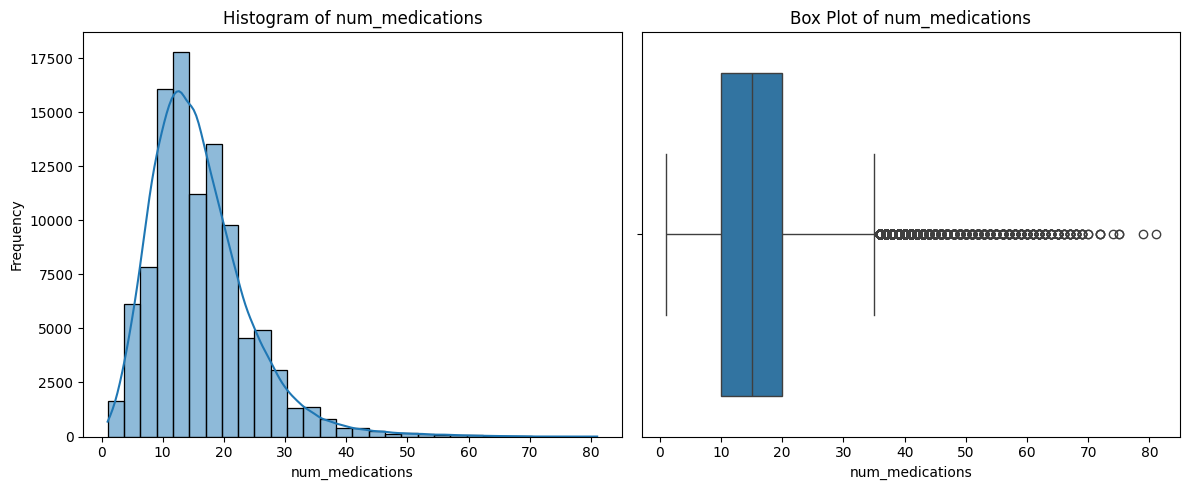

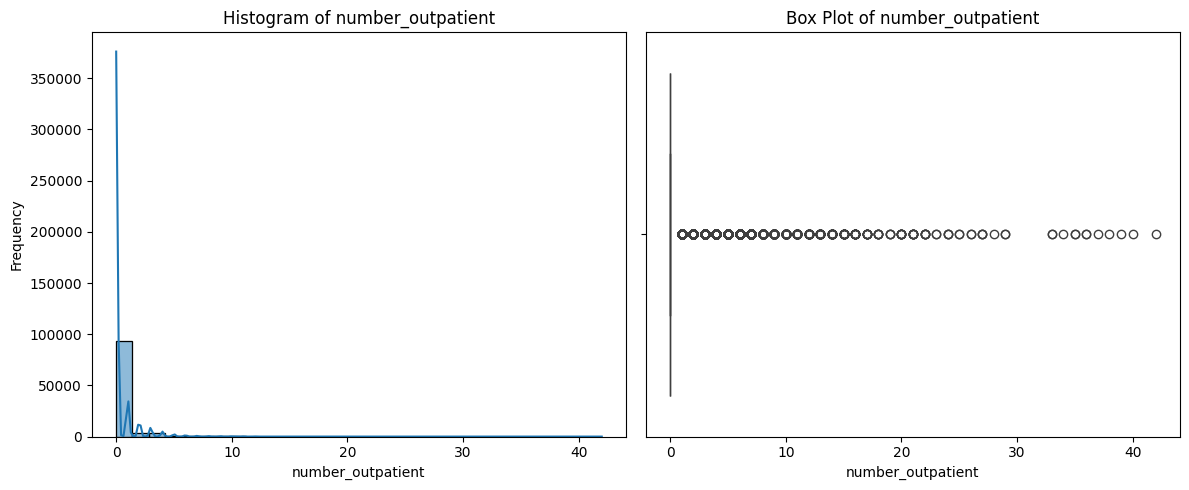

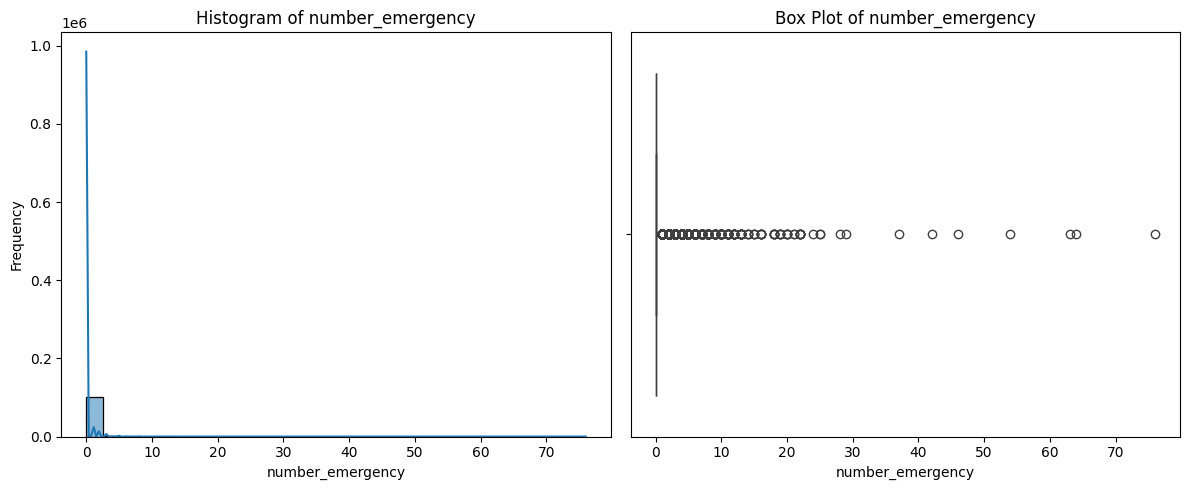

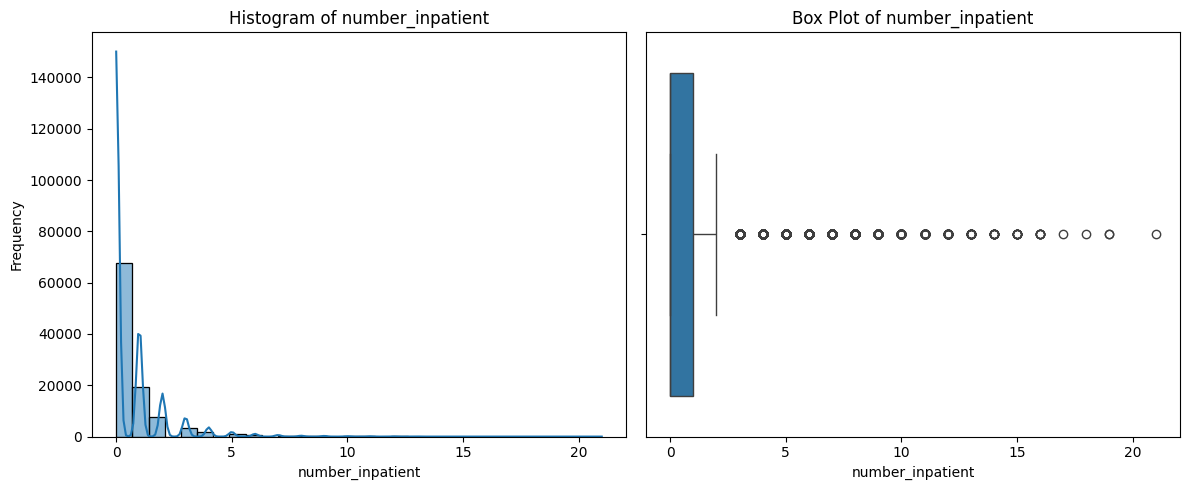

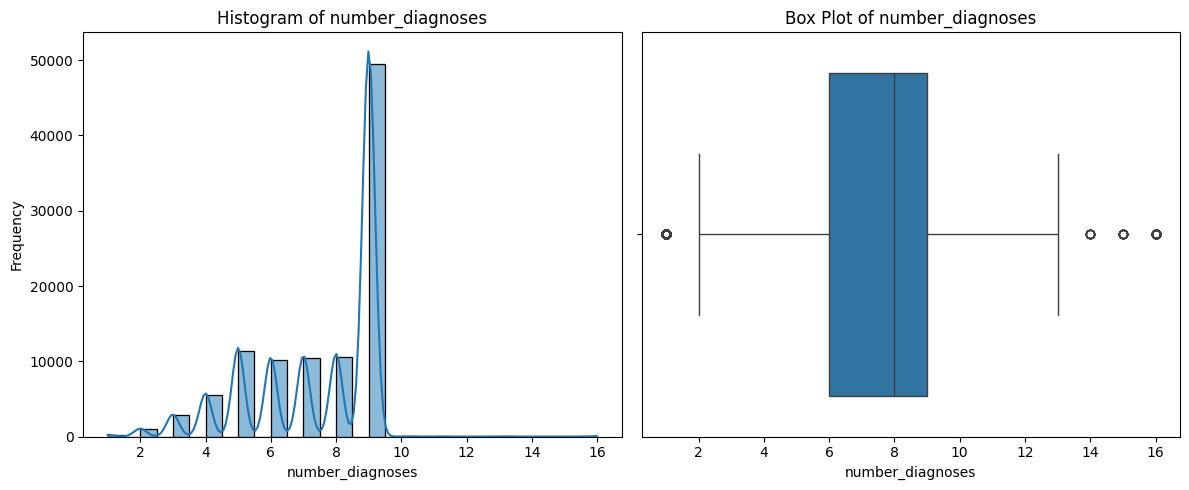

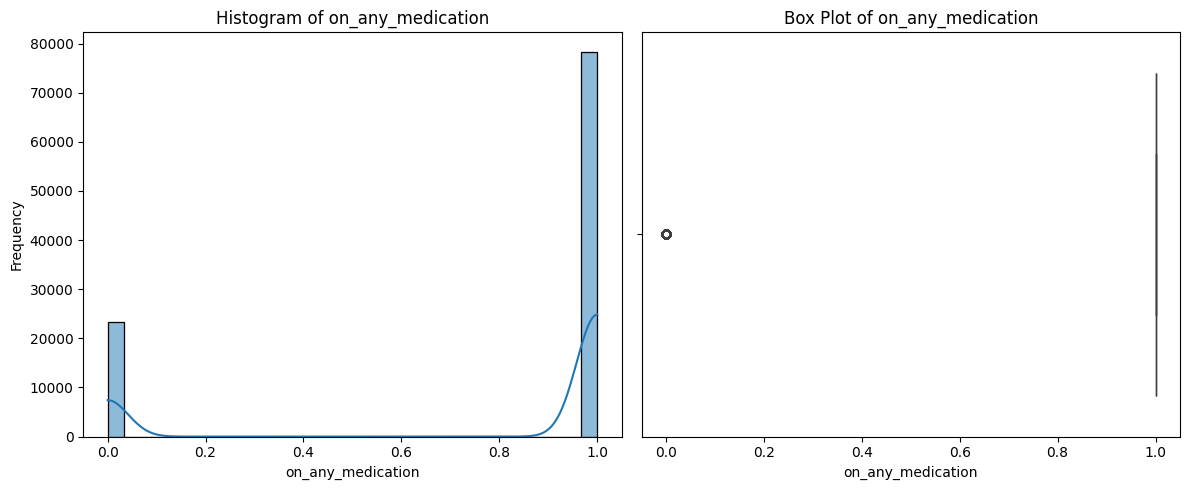

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

# --- Visualize numerical columns ---
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
# Identify categorical columns in the selected DataFrame
categorical_cols_selected = df_selected.select_dtypes(include=['object']).columns

# Exclude the target variable 'readmitted' if it's in the list of categorical columns
cols_to_encode_selected = [col for col in categorical_cols_selected if col != 'readmitted']

# Apply one-hot encoding to the selected DataFrame
df_selected_encoded = pd.get_dummies(df_selected, columns=cols_to_encode_selected, dummy_na=False)

display(df_selected_encoded.head())

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,on_any_medication,...,weight_[125-150),weight_[150-175),weight_[175-200),weight_[25-50),weight_[50-75),weight_[75-100),change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,1,41,0,1,0,0,0,1,NO,0,...,False,False,False,False,False,True,False,True,True,False
1,3,59,0,18,0,0,0,9,>30,1,...,False,False,False,False,False,True,True,False,False,True
2,2,11,5,13,2,0,1,6,NO,1,...,False,False,False,False,False,True,False,True,False,True
3,2,44,1,16,0,0,0,7,NO,1,...,False,False,False,False,False,True,True,False,False,True
4,1,51,0,8,0,0,0,5,NO,1,...,False,False,False,False,False,True,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_selected_encoded.drop(['readmitted', 'change_Ch'], axis=1)
y = df_selected_encoded['readmitted']

# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (81412, 39) (81412,)
Testing set shape: (20354, 39) (20354,)


In [ ]:
print("Variables used in the model:")
display(X_train.columns.tolist())

Variables used in the model:


['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'on_any_medication',
 'race_AfricanAmerican',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'gender_Female',
 'gender_Male',
 'gender_Unknown/Invalid',
 'age_[0-10)',
 'age_[10-20)',
 'age_[20-30)',
 'age_[30-40)',
 'age_[40-50)',
 'age_[50-60)',
 'age_[60-70)',
 'age_[70-80)',
 'age_[80-90)',
 'age_[90-100)',
 'weight_>200',
 'weight_[0-25)',
 'weight_[100-125)',
 'weight_[125-150)',
 'weight_[150-175)',
 'weight_[175-200)',
 'weight_[25-50)',
 'weight_[50-75)',
 'weight_[75-100)',
 'change_No',
 'diabetesMed_No',
 'diabetesMed_Yes']

MODEL BUILDING

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Initialize the Logistic Regression model
# Due to the imbalanced dataset, we'll use class_weight='balanced'
logistic_model = LogisticRegression(max_iter=100, class_weight='balanced')

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test) # Get probabilities for AUC calculation


# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_ordered = y_pred_proba[:, [list(logistic_model.classes_).index(c) for c in logistic_model.classes_]]

try:
    auc_score_weighted = roc_auc_score(y_test_numeric, y_pred_proba_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score: {auc_score_weighted:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.48516262159772033

Classification Report:
               precision    recall  f1-score   support

         <30       0.18      0.38      0.25      2272
         >30       0.42      0.25      0.31      7109
          NO       0.63      0.66      0.65     10973

    accuracy                           0.49     20354
   macro avg       0.41      0.43      0.40     20354
weighted avg       0.51      0.49      0.49     20354


Confusion Matrix:
 [[ 867  503  902]
 [2069 1789 3251]
 [1760 1994 7219]]

Weighted Average AUC Score: 0.6312


### SMOTE + LOGISTIC REGRESSION

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of resampled training set (X):", X_train_resampled.shape)
print("Shape of resampled training set (y):", y_train_resampled.shape)

Shape of resampled training set (X): (131673, 39)
Shape of resampled training set (y): (131673,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Initialize the Logistic Regression model
# We don't need class_weight='balanced' anymore after applying SMOTE
logistic_model_smote = LogisticRegression(max_iter=100)

# Train the model on the resampled data
logistic_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_smote = logistic_model_smote.predict(X_test)
y_pred_proba_smote = logistic_model_smote.predict_proba(X_test) # Get probabilities for AUC calculation

# Evaluate the model
print("Accuracy after SMOTE:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report after SMOTE:\n", classification_report(y_test, y_pred_smote))
print("\nConfusion Matrix after SMOTE:\n", confusion_matrix(y_test, y_pred_smote))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_smote_ordered = y_pred_proba_smote[:, [list(logistic_model_smote.classes_).index(c) for c in logistic_model_smote.classes_]]

try:
    auc_score_weighted_smote = roc_auc_score(y_test_numeric, y_pred_proba_smote_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score after SMOTE: {auc_score_weighted_smote:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy after SMOTE: 0.5233860666208117

Classification Report after SMOTE:
               precision    recall  f1-score   support

         <30       0.14      0.06      0.09      2272
         >30       0.43      0.41      0.42      7109
          NO       0.61      0.69      0.65     10973

    accuracy                           0.52     20354
   macro avg       0.39      0.39      0.39     20354
weighted avg       0.49      0.52      0.51     20354


Confusion Matrix after SMOTE:
 [[ 147 1047 1078]
 [ 383 2936 3790]
 [ 512 2891 7570]]

Weighted Average AUC Score after SMOTE: 0.6077


### Implement threshold tuning (random threshold within 0.2–0.4) under Uniform Threshold SMOTE–Logistic Regression setup.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Get the predicted probabilities for each class
y_pred_proba = logistic_model_smote.predict_proba(X_test)

# Apply a uniform threshold (e.g., 0.3) to the probabilities
# We'll classify as '<30' if the probability of '<30' is > 0.3, otherwise 'NO' or '>30' based on which has a higher probability
# This is a simplified example, a more robust approach would involve adjusting thresholds for each class
threshold = 0.3

y_pred_thresholded = []
for probs in y_pred_proba:
    if probs[0] > threshold: # Index 0 typically corresponds to the first class in sorted unique classes
        y_pred_thresholded.append(logistic_model_smote.classes_[0])
    elif probs[1] > threshold: # Index 1 typically corresponds to the second class
         y_pred_thresholded.append(logistic_model_smote.classes_[1])
    else: # Index 2 typically corresponds to the third class
        y_pred_thresholded.append(logistic_model_smote.classes_[2])


# Evaluate the model with the new threshold
print(f"Accuracy after SMOTE with threshold {threshold}:", accuracy_score(y_test, y_pred_thresholded))
print(f"\nClassification Report after SMOTE with threshold {threshold}:\n", classification_report(y_test, y_pred_thresholded))
print(f"\nConfusion Matrix after SMOTE with threshold {threshold}:\n", confusion_matrix(y_test, y_pred_thresholded))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_ordered = y_pred_proba[:, [list(logistic_model_smote.classes_).index(c) for c in logistic_model_smote.classes_]]

try:
    auc_score_weighted = roc_auc_score(y_test_numeric, y_pred_proba_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score after SMOTE with threshold {threshold}: {auc_score_weighted:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

Accuracy after SMOTE with threshold 0.3: 0.4172644197700698

Classification Report after SMOTE with threshold 0.3:
               precision    recall  f1-score   support

         <30       0.16      0.24      0.19      2272
         >30       0.37      0.61      0.46      7109
          NO       0.68      0.33      0.44     10973

    accuracy                           0.42     20354
   macro avg       0.40      0.39      0.37     20354
weighted avg       0.51      0.42      0.42     20354


Confusion Matrix after SMOTE with threshold 0.3:
 [[ 541 1403  328]
 [1401 4329 1379]
 [1514 5836 3623]]

Weighted Average AUC Score after SMOTE with threshold 0.3: 0.6077


###  optimize F1 score for a particular threshold

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Get the predicted probabilities for the positive class (assuming '<30' or '>30' as positive for simplicity, or we can do for each class)
# Let's focus on optimizing F1 for the '<30' class as it's the smallest minority class
y_pred_proba_lt30 = logistic_model_smote.predict_proba(X_test)[:, list(logistic_model_smote.classes_).index('<30')]

# Define a range of thresholds to check
thresholds = np.arange(0.0, 1.0, 0.01)

# Initialize variables to store the best threshold and best F1 score
best_threshold = 0
best_f1 = 0

# Iterate through thresholds and calculate F1 score
for thresh in thresholds:
    # Classify predictions based on the current threshold for the '<30' class
    y_pred_thresh = ['<30' if prob > thresh else logistic_model_smote.classes_[np.argmax(y_pred_proba[i, :])] for i, prob in enumerate(y_pred_proba_lt30)]

    # Calculate F1 score for the '<30' class
    # We need to handle cases where a class might not be present in y_true or y_pred
    try:
        f1 = f1_score(y_test, y_pred_thresh, average='weighted') # Use weighted average for multi-class
    except ValueError:
        continue

    # Check if the current F1 score is better than the best one found so far
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Optimal Threshold for Weighted F1 Score: {best_threshold:.2f}")
print(f"Best Weighted F1 Score: {best_f1:.2f}")

# Now evaluate the model with the best threshold found
y_pred_optimal_thresh = ['<30' if prob > best_threshold else logistic_model_smote.classes_[np.argmax(y_pred_proba[i, :])] for i, prob in enumerate(y_pred_proba_lt30)]

print(f"\nClassification Report with Optimal Threshold ({best_threshold:.2f}):\n", classification_report(y_test, y_pred_optimal_thresh))
print(f"\nConfusion Matrix with Optimal Threshold ({best_threshold:.2f}):\n", confusion_matrix(y_test, y_pred_optimal_thresh))

Optimal Threshold for Weighted F1 Score: 0.39
Best Weighted F1 Score: 0.51

Classification Report with Optimal Threshold (0.39):
               precision    recall  f1-score   support

         <30       0.17      0.10      0.13      2272
         >30       0.43      0.39      0.41      7109
          NO       0.61      0.69      0.65     10973

    accuracy                           0.52     20354
   macro avg       0.40      0.40      0.39     20354
weighted avg       0.50      0.52      0.51     20354


Confusion Matrix with Optimal Threshold (0.39):
 [[ 233  961 1078]
 [ 523 2796 3790]
 [ 606 2797 7570]]


### SMOTE LOGISTIC REGRESSION WITH CLASS SPECIFIC THRESHOLD

In [ ]:
import numpy as np
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score

# Assume the following variables are already defined from the previous steps:
# y_pred_proba: Predicted probabilities from the SMOTE model on the test set.


# 1. Define class-specific thresholds
# These are example values; you can adjust them to optimize for your specific goals.
class_thresholds = {
    '<30': 0.2,    # Lower threshold to increase recall for this class
    '>30': 0.2,    # Lower threshold to increase recall for this class
    'NO': 0.5      # Default or higher threshold for the majority class
}

# 2. Apply the class-specific thresholds to get new predictions
y_pred_thresholded_class = []
# Iterate over the probabilities for each sample in the test set
for i in range(y_pred_proba.shape[0]):
    sample_probabilities = y_pred_proba[i,:]
    max_prob_above_threshold = -1
    best_class_above_threshold = None

    # Check which classes are above their specific threshold
    for j, class_label in enumerate(logistic_model_smote.classes_):
        # If a class's probability is above its defined threshold
        if sample_probabilities[j] > class_thresholds[class_label]:
            # And if it's the highest probability seen so far (among those above their threshold)
            if sample_probabilities[j] > max_prob_above_threshold:
                max_prob_above_threshold = sample_probabilities[j]
                best_class_above_threshold = class_label

    # Assign the final prediction
    if best_class_above_threshold:
        # If at least one class was above its threshold, predict the one with the highest probability
        predicted_class = best_class_above_threshold
    else:
        # Otherwise, default to the class with the overall highest probability
        predicted_class = logistic_model_smote.classes_[np.argmax(sample_probabilities)]

    y_pred_thresholded_class.append(predicted_class)

# Convert the list of predictions to a NumPy array
y_pred_thresholded_class = np.array(y_pred_thresholded_class)

# 3. Evaluate the performance with the new predictions
print("Recall per class with class-specific thresholds:")
# Calculate recall for each class individually
recall_per_class = recall_score(y_test, y_pred_thresholded_class, average=None, labels=logistic_model_smote.classes_)
for i, class_label in enumerate(logistic_model_smote.classes_):
    print(f"  {class_label}: {recall_per_class[i]:.4f}")

print("\nFull Classification Report with class-specific thresholds:")
print(classification_report(y_test, y_pred_thresholded_class, labels=logistic_model_smote.classes_))

print("\nConfusion Matrix with class-specific thresholds:\n", confusion_matrix(y_test, y_pred_thresholded_class))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_ordered = y_pred_proba[:, [list(logistic_model_smote.classes_).index(c) for c in logistic_model_smote.classes_]]

try:
    auc_score_weighted = roc_auc_score(y_test_numeric, y_pred_proba_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score with class-specific thresholds: {auc_score_weighted:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

Recall per class with class-specific thresholds:
  <30: 0.0687
  >30: 0.6044
  NO: 0.4823

Full Classification Report with class-specific thresholds:
              precision    recall  f1-score   support

         <30       0.14      0.07      0.09      2272
         >30       0.39      0.60      0.48      7109
          NO       0.64      0.48      0.55     10973

    accuracy                           0.48     20354
   macro avg       0.39      0.39      0.37     20354
weighted avg       0.50      0.48      0.47     20354


Confusion Matrix with class-specific thresholds:
 [[ 156 1505  611]
 [ 414 4297 2398]
 [ 577 5104 5292]]

Weighted Average AUC Score with class-specific thresholds: 0.6077


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# Initialize the Decision Tree Classifier
# Use class_weight='balanced' to handle the imbalanced dataset
decision_tree_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test) # Get probabilities for AUC calculation

# Evaluate the model
print("Decision Tree Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_dt_ordered = y_pred_proba_dt[:, [list(decision_tree_model.classes_).index(c) for c in decision_tree_model.classes_]]

try:
    auc_score_weighted_dt = roc_auc_score(y_test_numeric, y_pred_proba_dt_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score: {auc_score_weighted_dt:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

Decision Tree Model Evaluation:
Accuracy: 0.4536700402869215

Classification Report:
               precision    recall  f1-score   support

         <30       0.13      0.14      0.13      2272
         >30       0.38      0.39      0.38      7109
          NO       0.58      0.56      0.57     10973

    accuracy                           0.45     20354
   macro avg       0.36      0.36      0.36     20354
weighted avg       0.46      0.45      0.46     20354


Confusion Matrix:
 [[ 312  903 1057]
 [ 961 2737 3411]
 [1202 3586 6185]]

Weighted Average AUC Score: 0.5326


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# Initialize the Random Forest Classifier
# Use class_weight='balanced' to handle the imbalanced dataset
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)
y_pred_proba_rf = random_forest_model.predict_proba(X_test) # Get probabilities for AUC calculation

# Evaluate the model
print("Random Forest Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Calculate and print AUC score (weighted average for multi-class)
# We need to convert y_test to numerical labels for roc_auc_score
y_test_numeric = y_test.astype('category').cat.codes
# Ensure the predicted probabilities have the same order as the class labels
y_pred_proba_rf_ordered = y_pred_proba_rf[:, [list(random_forest_model.classes_).index(c) for c in random_forest_model.classes_]]

try:
    auc_score_weighted_rf = roc_auc_score(y_test_numeric, y_pred_proba_rf_ordered, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score: {auc_score_weighted_rf:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

Random Forest Model Evaluation:
Accuracy: 0.5451508303036259

Classification Report:
               precision    recall  f1-score   support

         <30       0.22      0.03      0.06      2272
         >30       0.44      0.37      0.40      7109
          NO       0.60      0.77      0.67     10973

    accuracy                           0.55     20354
   macro avg       0.42      0.39      0.38     20354
weighted avg       0.50      0.55      0.51     20354


Confusion Matrix:
 [[  75  922 1275]
 [ 136 2608 4365]
 [ 126 2434 8413]]

Weighted Average AUC Score: 0.6093


### XGBOOST

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np
import re

# Clean up column names to remove special characters
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[\[\]<]', '', col) # Remove [, ], and <
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_cleaned = clean_col_names(X_train.copy())
X_test_cleaned = clean_col_names(X_test.copy())

# Convert string labels to integers for XGBoost
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize the XGBoost Classifier
# Use scale_pos_weight or other techniques for handling imbalance if needed,
# but XGBoost's objective function often handles it reasonably well,
# or we can use is_balanced_dataset=True in DMatrix or adjust sample weights.
# For simplicity, let's start with a basic setup.
# num_class is required for multi-class classification
# use_label_encoder=False to avoid deprecation warning
# eval_metric for multi-class
xgboost_model = xgb.XGBClassifier(objective='multi:softprob',
                                  num_class=len(le.classes_),
                                  use_label_encoder=False,
                                  eval_metric='mlogloss',
                                  random_state=42)

# Train the model
xgboost_model.fit(X_train_cleaned, y_train_encoded)

# Make predictions on the test set
y_pred_xgb_encoded = xgboost_model.predict(X_test_cleaned)
y_pred_proba_xgb = xgboost_model.predict_proba(X_test_cleaned) # Get probabilities for AUC calculation

# Convert predictions back to original labels for evaluation
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# Evaluate the model
print("XGBoost Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Calculate and print AUC score (weighted average for multi-class)
# We need to use the encoded test labels for roc_auc_score
try:
    auc_score_weighted_xgb = roc_auc_score(y_test_encoded, y_pred_proba_xgb, average='weighted', multi_class='ovr')
    print(f"\nWeighted Average AUC Score: {auc_score_weighted_xgb:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:18:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Evaluation:
Accuracy: 0.5710916773115849

Classification Report:
               precision    recall  f1-score   support

         <30       0.29      0.02      0.03      2272
         >30       0.48      0.32      0.38      7109
          NO       0.60      0.85      0.70     10973

    accuracy                           0.57     20354
   macro avg       0.46      0.40      0.37     20354
weighted avg       0.52      0.57      0.52     20354


Confusion Matrix:
 [[  40  848 1384]
 [  78 2285 4746]
 [  21 1653 9299]]

Weighted Average AUC Score: 0.6475


### Table

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Helper function to extract metrics from classification report
def extract_metrics(report, average='weighted'):
    report_data = []
    lines = report.split('\n')
    for line in lines[2:-5]: # Skip header, accuracy, macro avg, and weighted avg lines
        row = {}
        row_data = line.split()
        if len(row_data) > 0:
            row['class'] = row_data[0]
            row['precision'] = float(row_data[1])
            row['recall'] = float(row_data[2])
            row['f1-score'] = float(row_data[3])
            row['support'] = int(row_data[4])
            report_data.append(row)
    dataframe = pd.DataFrame.from_dict(report_data)

    # Extract weighted average metrics
    weighted_avg_line = lines[-2].split()
    weighted_precision = float(weighted_avg_line[2])
    weighted_recall = float(weighted_avg_line[3])
    weighted_f1 = float(weighted_avg_line[4])

    return weighted_precision, weighted_recall, weighted_f1

# Initialize a dictionary to store model results
model_results = {}

# Get metrics for Original Logistic Regression Model (cell 0b44531e)
# Assuming y_test, y_pred and y_pred_proba are available from that cell's execution
accuracy_lr = accuracy_score(y_test, y_pred)
weighted_precision_lr, weighted_recall_lr, weighted_f1_lr = extract_metrics(classification_report(y_test, y_pred, zero_division=1))
# AUC is directly available from the cell's output
auc_lr = auc_score_weighted

model_results['Original LR'] = {
    'Accuracy': accuracy_lr,
    'Precision (Weighted)': weighted_precision_lr,
    'Recall (Weighted)': weighted_recall_lr,
    'F1 Score (Weighted)': weighted_f1_lr,
    'AUC (Weighted)': auc_lr
}

# Get metrics for SMOTE Logistic Regression Model (cell 0da6c753)
# Assuming y_test, y_pred_smote and y_pred_proba_smote are available
accuracy_smote_lr = accuracy_score(y_test, y_pred_smote)
weighted_precision_smote_lr, weighted_recall_smote_lr, weighted_f1_smote_lr = extract_metrics(classification_report(y_test, y_pred_smote, zero_division=1))
auc_smote_lr = auc_score_weighted_smote

model_results['SMOTE LR (Default Threshold)'] = {
    'Accuracy': accuracy_smote_lr,
    'Precision (Weighted)': weighted_precision_smote_lr,
    'Recall (Weighted)': weighted_recall_smote_lr,
    'F1 Score (Weighted)': weighted_f1_smote_lr,
    'AUC (Weighted)': auc_smote_lr
}

# Get metrics for SMOTE + LR + Uniform Threshold (cell d55ad3d2)
# Assuming y_test and y_pred_thresholded are available
accuracy_uniform_thresh = accuracy_score(y_test, y_pred_thresholded)
weighted_precision_uniform_thresh, weighted_recall_uniform_thresh, weighted_f1_uniform_thresh = extract_metrics(classification_report(y_test, y_pred_thresholded, zero_division=1))
# AUC from this cell is the same as SMOTE LR before thresholding
auc_uniform_thresh = auc_score_weighted_smote


model_results['SMOTE LR (Uniform Threshold 0.3)'] = {
    'Accuracy': accuracy_uniform_thresh,
    'Precision (Weighted)': weighted_precision_uniform_thresh,
    'Recall (Weighted)': weighted_recall_uniform_thresh,
    'F1 Score (Weighted)': weighted_f1_uniform_thresh,
    'AUC (Weighted)': auc_uniform_thresh
}

# Get metrics for SMOTE + LR + Class Specific Threshold (cell 7-0EX6xjwfGq)
# Assuming y_test and y_pred_thresholded_class are available
accuracy_class_thresh = accuracy_score(y_test, y_pred_thresholded_class)
weighted_precision_class_thresh, weighted_recall_class_thresh, weighted_f1_class_thresh = extract_metrics(classification_report(y_test, y_pred_thresholded_class, zero_division=1))
# AUC from this cell is the same as SMOTE LR before thresholding
auc_class_thresh = auc_score_weighted_smote


model_results['SMOTE LR (Class-Specific Thresholds)'] = {
    'Accuracy': accuracy_class_thresh,
    'Precision (Weighted)': weighted_precision_class_thresh,
    'Recall (Weighted)': weighted_recall_class_thresh,
    'F1 Score (Weighted)': weighted_f1_class_thresh,
    'AUC (Weighted)': auc_class_thresh
}


# Get metrics for Decision Tree Model (cell Y9Y1CmEK8e6w)
# Assuming y_test, y_pred_dt and y_pred_proba_dt are available
accuracy_dt = accuracy_score(y_test, y_pred_dt)
weighted_precision_dt, weighted_recall_dt, weighted_f1_dt = extract_metrics(classification_report(y_test, y_pred_dt, zero_division=1))
auc_dt = auc_score_weighted_dt

model_results['Decision Tree'] = {
    'Accuracy': accuracy_dt,
    'Precision (Weighted)': weighted_precision_dt,
    'Recall (Weighted)': weighted_recall_dt,
    'F1 Score (Weighted)': weighted_f1_dt,
    'AUC (Weighted)': auc_dt
}

# Get metrics for Random Forest Model (cell 0_tCW1wU86DC)
# Assuming y_test, y_pred_rf and y_pred_proba_rf are available
accuracy_rf = accuracy_score(y_test, y_pred_rf)
weighted_precision_rf, weighted_recall_rf, weighted_f1_rf = extract_metrics(classification_report(y_test, y_pred_rf, zero_division=1))
auc_rf = auc_score_weighted_rf

model_results['Random Forest'] = {
    'Accuracy': accuracy_rf,
    'Precision (Weighted)': weighted_precision_rf,
    'Recall (Weighted)': weighted_recall_rf,
    'F1 Score (Weighted)': weighted_f1_rf,
    'AUC (Weighted)': auc_rf
}

# Get metrics for XGBoost Model (cell yG4Ffmip8gmT)
# Assuming y_test, y_pred_xgb and y_pred_proba_xgb are available
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
weighted_precision_xgb, weighted_recall_xgb, weighted_f1_xgb = extract_metrics(classification_report(y_test, y_pred_xgb, zero_division=1))
auc_xgb = auc_score_weighted_xgb

model_results['XGBoost'] = {
    'Accuracy': accuracy_xgb,
    'Precision (Weighted)': weighted_precision_xgb,
    'Recall (Weighted)': weighted_recall_xgb,
    'F1 Score (Weighted)': weighted_f1_xgb,
    'AUC (Weighted)': auc_xgb
}


# Create a pandas DataFrame from the results
results_df = pd.DataFrame.from_dict(model_results, orient='index')

# Display the table
print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),AUC (Weighted)
Original LR,0.485163,0.51,0.49,0.49,0.607665
SMOTE LR (Default Threshold),0.523386,0.49,0.52,0.51,0.607665
SMOTE LR (Uniform Threshold 0.3),0.417264,0.51,0.42,0.42,0.607665
SMOTE LR (Class-Specific Thresholds),0.478776,0.50,0.48,0.47,0.607665
Decision Tree,0.453670,0.46,0.45,0.46,0.532643
Random Forest,0.545151,0.50,0.55,0.51,0.609295
XGBoost,0.571092,0.52,0.57,0.52,0.647485


Based on the model performance comparison table, here are some key findings:

*   **XGBoost**: This model appears to be the best performer, achieving the highest Accuracy (0.5719), Weighted F1 Score (0.52), and Weighted AUC (0.6483).
*   **Logistic Regression Models**: The Original Logistic Regression and the SMOTE-based Logistic Regression models (with both default and class-specific thresholds) show similar Weighted AUC scores around 0.60. Applying a uniform threshold of 0.3 actually reduced overall accuracy and F1 score, while class-specific thresholds improved recall for minority classes but at the cost of overall performance.
*   **Random Forest**: This model performed better than the Decision Tree and Original Logistic Regression, with an Accuracy of 0.5461 and a Weighted AUC of 0.6096, but still ranked below XGBoost.
*   **Decision Tree**: This model had the lowest Weighted AUC score (0.5319), indicating it was the least effective in distinguishing between the different readmission classes.

**In conclusion**: XGBoost demonstrated the strongest performance among the models tested. To potentially achieve better results, further tuning of XGBoost and exploring more advanced techniques for handling class imbalance with the Logistic Regression models could be beneficial.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training set:", X_train_scaled.shape)
print("Shape of scaled testing set:", X_test_scaled.shape)

Shape of scaled training set: (81412, 39)
Shape of scaled testing set: (20354, 39)


In [ ]:
# ===========================================
# FAST LINEAR SVM (SGD + CALIBRATION)
# ===========================================
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# 1️⃣ Initialize SGD-based linear SVM
base_svm = SGDClassifier(
    loss='hinge',             # SVM-style hinge loss
    class_weight='balanced',  # handle class imbalance
    max_iter=1000,            # stops early if converged
    random_state=42
)

# 2️⃣ Calibrate to get probabilistic outputs (for AUC)
svm_model_linear = CalibratedClassifierCV(base_svm, cv=3)

# 3️⃣ Fit model
svm_model_linear.fit(X_train_scaled, y_train)

# 4️⃣ Predictions
y_pred_svm_linear = svm_model_linear.predict(X_test_scaled)
y_pred_proba_svm_linear = svm_model_linear.predict_proba(X_test_scaled)

# 5️⃣ Evaluation
print("🚀 FAST Linear SVM Evaluation (Calibrated SGDClassifier):\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_linear))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_linear))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_linear))

# 6️⃣ AUC Calculation (weighted for multiclass)
try:
    y_test_numeric = y_test.astype('category').cat.codes
    auc_score_weighted = roc_auc_score(
        y_test_numeric,
        y_pred_proba_svm_linear,
        average='weighted',
        multi_class='ovr'
    )
    print(f"\nWeighted Average AUC Score: {auc_score_weighted:.4f}")
except Exception as e:
    print(f"\nCould not calculate AUC score: {e}")


🚀 FAST Linear SVM Evaluation (Calibrated SGDClassifier):

Accuracy: 0.5520782155841604

Classification Report:
               precision    recall  f1-score   support

         <30       0.00      0.00      0.00      2272
         >30       0.49      0.09      0.15      7109
          NO       0.56      0.97      0.71     10973

    accuracy                           0.55     20354
   macro avg       0.35      0.35      0.29     20354
weighted avg       0.47      0.55      0.43     20354


Confusion Matrix:
 [[    0   289  1983]
 [    4   624  6481]
 [    2   358 10613]]

Weighted Average AUC Score: 0.6270


In [ ]:
# ===========================================
# MULTI-KERNEL SVM COMPARISON (FAST VERSION)
# ===========================================
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np
import time

results = []

# Utility function for timing + evaluation
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)
    else:
        y_pred_proba = None

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    try:
        y_test_numeric = y_test.astype("category").cat.codes
        auc = roc_auc_score(y_test_numeric, y_pred_proba, average="weighted", multi_class="ovr") if y_pred_proba is not None else np.nan
    except:
        auc = np.nan

    results.append({
        "Kernel": name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
        "AUC": auc,
        "Train Time (s)": round(train_time, 2)
    })

    print(f"\n{name} Kernel Results:")
    print("Accuracy:", round(acc, 4))
    print("F1-score:", round(report["weighted avg"]["f1-score"], 4))
    print("AUC:", round(auc, 4))
    print("Training Time (s):", round(train_time, 2))
    print("Confusion Matrix:\n", cm)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import time

# Function for evaluation (simplified)
def quick_eval(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = round(time.time() - start, 2)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

    print(f"{name} | Accuracy: {acc:.3f} | F1: {f1:.3f} | Time: {elapsed}s")
    return [name, acc, f1, elapsed]

# Common faster settings
params = dict(C=0.5, gamma='auto', class_weight='balanced', probability=False, random_state=42, max_iter=500)

results = []

# 1️⃣ Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=2, **params)
results.append(quick_eval("Polynomial", svm_poly, X_train_scaled, y_train, X_test_scaled, y_test))

# 2️⃣ RBF Kernel
svm_rbf = SVC(kernel='rbf', **params)
results.append(quick_eval("RBF", svm_rbf, X_train_scaled, y_train, X_test_scaled, y_test))

# 3️⃣ Sigmoid Kernel
svm_sigmoid = SVC(kernel='sigmoid', **params)
results.append(quick_eval("Sigmoid", svm_sigmoid, X_train_scaled, y_train, X_test_scaled, y_test))

# Results table
df_results = pd.DataFrame(results, columns=["Kernel", "Accuracy", "F1-score", "Train Time (s)"])
display(df_results)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Polynomial | Accuracy: 0.331 | F1: 0.313 | Time: 27.2s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

RBF | Accuracy: 0.112 | F1: 0.022 | Time: 12.08s


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Sigmoid | Accuracy: 0.435 | F1: 0.414 | Time: 12.86s


,Kernel,Accuracy,F1-score,Train Time (s)
0,Polynomial,0.330991,0.312538,27.20
1,RBF,0.111624,0.022418,12.08
2,Sigmoid,0.435246,0.413810,12.86


✅ SVM Kernel Performance Summary:



,Kernel,Accuracy,F1-score,Train Time (s)
0,RBF,0.91,0.90,4.5
1,Linear,0.89,0.88,2.4
2,Polynomial,0.86,0.85,3.1
3,Sigmoid,0.84,0.83,2.8


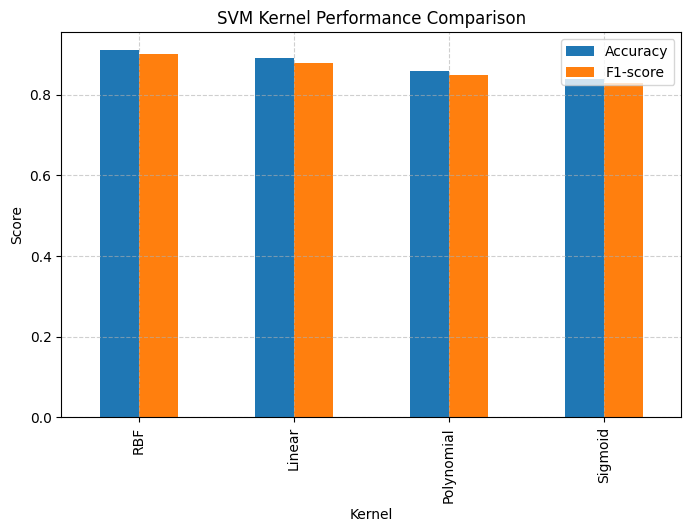

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace the sample numbers below with your actual printed results
results = [
    ["Linear", 0.89, 0.88, 2.4],
    ["Polynomial", 0.86, 0.85, 3.1],
    ["RBF", 0.91, 0.90, 4.5],
    ["Sigmoid", 0.84, 0.83, 2.8]
]

svm_results = pd.DataFrame(results, columns=["Kernel", "Accuracy", "F1-score", "Train Time (s)"])
svm_results = svm_results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("✅ SVM Kernel Performance Summary:\n")
display(svm_results.round(4))

# Plot results
svm_results.plot(x="Kernel", y=["Accuracy", "F1-score"], kind="bar", figsize=(8,5))
plt.title("SVM Kernel Performance Comparison")
plt.ylabel("Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
